--------------------------
# Setting Up

In [1]:
import os
import time
import glob
import re
import itertools
import random


import torch
from torch.optim import Adam, SparseAdam, RMSprop, SGD
from torch.utils.data import TensorDataset, DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics import Accuracy, Precision, Recall, MeanSquaredError
from torchview import draw_graph

from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import confusion_matrix

from scipy.stats import zscore
import numpy as np
import fractions
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors

from pathlib import Path
from tqdm import tqdm

import IPython
from IPython.display import Image, Audio

from midi2audio import FluidSynth
from music21 import corpus, converter, instrument, tempo, meter, note, pitch, stream, chord, duration, midi
import music21

import warnings
warnings.filterwarnings('ignore')

In [2]:
np.random.seed(42)

**music21**

Ref: https://web.mit.edu/music21/doc/usersGuide

- **wiki set theory:** https://en.wikipedia.org/wiki/Set_theory_(music)
- **wiki pitch class:** https://en.wikipedia.org/wiki/Pitch_class

In [3]:
print(music21.__doc__)


The music21 Framework is Copyright © 2006-2022 Michael Scott Asato Cuthbert.

Some Rights Reserved
Released under the BSD (3-clause) license.  See license.txt.

See license.txt file for the full license which represents your legal
obligations in using, modifying, or distributing music21.

Roughly speaking, this means that anyone can use this software for
free, they can distribute it to anyone, so long as this acknowledgment
of copyright and ownership remain publicly accessible.  You may also
modify this software or use it in your own programs so long as you do
so long as you make your product available
under the same license.  You may also link to this code as a library
from your sold, proprietary commercial product so long as this code
remains open and accessible, this license is made accessible,
and the developers are credited.

The development of music21 was supported by grants
from the Seaver Institute and the NEH/Digging into Data Challenge,
with the support of the MIT
Music and 

In [4]:
print(torch.__doc__)


The torch package contains data structures for multi-dimensional
tensors and defines mathematical operations over these tensors.
Additionally, it provides many utilities for efficient serialization of
Tensors and arbitrary types, and other useful utilities.

It has a CUDA counterpart, that enables you to run your tensor computations
on an NVIDIA GPU with compute capability >= 3.0.



In [5]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
print(f'selcted tensor device: {DEVICE}')

selcted tensor device: cuda:0


# load files
load random sample of all files

In [6]:


path = Path.cwd().joinpath('archive')
files = list(path.glob('*.mid'))# ["JS_dontneednodoc", "Sham_Time", "slinky", "the_sight_of_spira", "john_sein_song", "ty_august"]


## VRAM is too small :'-)
n_files = 16 #len(files)

scores = []
scores_file = []

for n, f in enumerate(random.sample(files, n_files)):
    file = path.joinpath(f)
    
    midifile = midi.MidiFile()
    midifile.open(file)
    midifile.read()
    
    tracks = [t for t in midifile.tracks if not any([e.channel == 16 for e in t.events])]
    
    
    
    for track in tracks:
        score = stream.Score()
        midi.translate.midiTrackToStream(track,                                            
            inputM21=score,
            forceSource=False, 
            quantizePost=False,
            ticksPerQuarter=midifile.ticksPerQuarterNote,
            quarterLengthDivisors=(4,3),
        )
        scores.append(score)
        scores_file.append(f)
    
    print(f'file:{file} found {len(tracks)} tracks!')

file:D:\Documents\Uni\Maschinelles Lernen\music generation\archive\Chameleon.mid found 2 tracks!
file:D:\Documents\Uni\Maschinelles Lernen\music generation\archive\Dr_Dre_Still_Dre.mid found 4 tracks!
file:D:\Documents\Uni\Maschinelles Lernen\music generation\archive\sandstorm.mid found 1 tracks!
file:D:\Documents\Uni\Maschinelles Lernen\music generation\archive\Come_Alive.mid found 2 tracks!
file:D:\Documents\Uni\Maschinelles Lernen\music generation\archive\slinky.mid found 3 tracks!
file:D:\Documents\Uni\Maschinelles Lernen\music generation\archive\chpn-p3.mid found 9 tracks!
file:D:\Documents\Uni\Maschinelles Lernen\music generation\archive\johnny_cash_personal_jesus.mid found 2 tracks!
file:D:\Documents\Uni\Maschinelles Lernen\music generation\archive\The-House-Of-The-Rising-Sun.mid found 11 tracks!
file:D:\Documents\Uni\Maschinelles Lernen\music generation\archive\the_sight_of_spira.mid found 2 tracks!
file:D:\Documents\Uni\Maschinelles Lernen\music generation\archive\Awake.mid fo

---------------------
# Extract the data


we should exclude time durations shorter than 64th notes (0.0625 timeunits)

In [7]:
## load note durations dict
NOTE_DURATIONS = duration.typeToDuration
NOTE_DURATIONS

{'duplex-maxima': 64.0,
 'maxima': 32.0,
 'longa': 16.0,
 'breve': 8.0,
 'whole': 4.0,
 'half': 2.0,
 'quarter': 1.0,
 'eighth': 0.5,
 '16th': 0.25,
 '32nd': 0.125,
 '64th': 0.0625,
 '128th': 0.03125,
 '256th': 0.015625,
 '512th': 0.0078125,
 '1024th': 0.00390625,
 '2048th': 0.001953125,
 'zero': 0.0}

In [8]:
filter_durations = True

if filter_durations:
    sl = slice(10, -1)
else:
    sl = slice(0)
    
print('durations to exclude:')
print(list(NOTE_DURATIONS.keys())[sl])
print(list(NOTE_DURATIONS.values())[sl])

def NOTE_SORT(value):
    sort = 0
    try:
        if isinstance(value, float):
            sort = np.argmax(np.isclose(value, list(NOTE_DURATIONS.values()), rtol=0.5))
        elif isinstance(value, str):    
            sort = list(NOTE_DURATIONS.keys()).index(value)
    except Exception as e:
        print(e)
    return sort    







durations to exclude:
['64th', '128th', '256th', '512th', '1024th', '2048th']
[0.0625, 0.03125, 0.015625, 0.0078125, 0.00390625, 0.001953125]


In [9]:
keys_keep = sorted(list(set(list(NOTE_DURATIONS.keys())) - set(list(NOTE_DURATIONS.keys())[sl])), key=NOTE_SORT) 
vals_keep = sorted(list(set(list(NOTE_DURATIONS.values())) - set(list(NOTE_DURATIONS.values())[sl])), key=NOTE_SORT) 
VALID_NOTE_DURATIONS = dict(itertools.zip_longest(*[keys_keep], *[vals_keep], fillvalue="-1"))
print('keeping durations:', VALID_NOTE_DURATIONS)

keeping durations: {'duplex-maxima': 64.0, 'maxima': 32.0, 'longa': 16.0, 'breve': 8.0, 'whole': 4.0, 'half': 2.0, 'quarter': 1.0, 'eighth': 0.5, '16th': 0.25, '32nd': 0.125, 'zero': 0.0}


### read scores into dataframes

In [10]:
score_dataframes = []

head = scores[0]
#print(dir(head))
itr = enumerate(zip(scores_file, scores))

for score_n,(fn, original_score) in itr:

    #original_score = score.chordify()
    
    ## laufender idx für note oder chords + rest
    idx = 0
    ## laufender idx für note oder chords
    last_idx = 0
    ## letzter erfolgreicher idx für note oder chords
    last_idx_ok = 0
    
    elements = []
    notes = []
    root_notes = []
    root_pitch = []
    cardinalities = [] 
    forteClasses = []
    inversions = []
    pcOriginals = []
    cardinalities_step = [] 
    forteClasses_step = []
    inversions_step = []
    pcOriginals_step = []
    pitches = []
    root_step = []
    seconds = []
    duration_step = []
    durations = []
    chord_intervals = []
    chords = []
    df_name = ""
    df_bpm = 0
    
    for element in original_score.flatten():    
        elements.append(element)
        if isinstance(element, instrument.Instrument):
            #print(score_n, idx, element)
            if 'Perc' in str(element):
                next(itr)
                break
            if idx <= 1:
                df_name = f'{fn}  - {element}'

        elif isinstance(element, chord.Chord):      
            c = chord.Chord(element.pitches, duration=element.duration)     
            chords.append(c)  ### append(element) enough??
            chord_intervals.append(c.commonName)
            (cardinality, forteClass, inversion, pcOriginal) = c.chordTablesAddress
            cardinalities.append(cardinality)
            forteClasses.append(forteClass)
            inversions.append(inversion)
            pcOriginals.append(pcOriginal)
            d_o = float(element.duration.quarterLength)
            d_idx = np.argmax(np.isclose(d_o, sorted(VALID_NOTE_DURATIONS.values()), rtol=0.5))
            d = sorted(VALID_NOTE_DURATIONS.values())[d_idx]
            durations.append(d)
            try:    
                duration_step.append(d - durations[idx - 2])
                
            except IndexError:
                duration_step.append(0)
                
            notes.append([n.nameWithOctave for n in element.pitches])
            pitches.append(np.array([p.ps for p in element.pitches]))
            root_notes.append(c.root().nameWithOctave)
            root_pitch.append(c.root().ps)
            try:
                root_step.append(c.root().ps - chords[last_idx].root().ps)
                cardinalities_step.append(cardinality - cardinalities[last_idx])
                forteClasses_step.append(forteClass - forteClasses[last_idx])
                inversions_step.append(inversion - inversions[last_idx])
                pcOriginals_step.append(pcOriginal - pcOriginals[last_idx])
            except chord.ChordException:
                root_step.append(0)
                cardinalities_step.append(0)
                forteClasses_step.append(0)
                inversions_step.append(0)
                pcOriginals_step.append(0)
            last_idx = idx 
            idx += 1
    
        elif isinstance(element, (note.Note, note.Rest)):
            idx += 1
            if element.isRest:
                r = str(element.name)
                chords.append(chord.Chord(None, duration=element.duration))
                chord_intervals.append(r)
                cardinalities.append(np.nan)
                forteClasses.append(np.nan)
                inversions.append(np.nan)
                pcOriginals.append(np.nan)
                cardinalities_step.append(np.nan)
                forteClasses_step.append(np.nan)
                inversions_step.append(np.nan)
                pcOriginals_step.append(np.nan)
                notes.append(r)
                pitches.append(np.nan)
                root_pitch.append(np.nan)
                root_notes.append(r)
                root_step.append(np.nan)
                #last_idx += 1
                ## fix durations
                d_o = float(element.duration.quarterLength.__round__(1))
                d_idx = np.argmax(np.isclose(d_o, sorted(VALID_NOTE_DURATIONS.values()), rtol=0.5))
                d = sorted(VALID_NOTE_DURATIONS.values())[d_idx]

            else:
                
                c = chord.Chord(element.nameWithOctave, duration=element.duration)
                chords.append(c)
                chord_intervals.append(c.commonName)
                (cardinality, forteClass, inversion, pcOriginal) = c.chordTablesAddress
                cardinalities.append(cardinality)
                forteClasses.append(forteClass)
                inversions.append(inversion)
                pcOriginals.append(pcOriginal)
                notes.append(str(element.nameWithOctave))
                pitches.append(np.array([element.pitch.ps]))
                root_notes.append(c.root().nameWithOctave)
                root_pitch.append(c.root().ps)
                
                try:
                    root_step.append(c.root().ps - chords[last_idx].root().ps)
                    cardinalities_step.append(cardinality - cardinalities[last_idx])
                    forteClasses_step.append(forteClass - forteClasses[last_idx])
                    inversions_step.append(inversion - inversions[last_idx])
                    pcOriginals_step.append(pcOriginal - pcOriginals[last_idx])
                    last_idx = idx - 1
                except chord.ChordException:
                    root_step.append(0)
                    cardinalities_step.append(0)
                    forteClasses_step.append(0)
                    inversions_step.append(0)
                    pcOriginals_step.append(0)
                    if last_idx <= 6:
                        last_idx += 1

                d_o = float(element.duration.quarterLength)
                d_idx = np.argmax(np.isclose(d_o, sorted(VALID_NOTE_DURATIONS.values()), rtol=0.5))
                d = sorted(VALID_NOTE_DURATIONS.values())[d_idx]
            durations.append(d)
            try:    
                duration_step.append(d - durations[idx - 2])
            except IndexError:
                duration_step.append(0)
        
                
        elif isinstance(element, tempo.MetronomeMark):
           
            df_bpm = element.getQuarterBPM()

        elif isinstance(element,meter.TimeSignature):
            pass
        else:
            pass

    
    if len(chords) <= 1:
        print(f'{df_name} error! len(chords) <= 1')
        continue
    #c.pitchedCommonName
    d = {
         'notes': notes,
         'note_pitches' : pitches, 
         'duration': durations,
         'duration_step': duration_step,
         'root_note': root_notes,
         'root_pitch': root_pitch,
         'root_step': root_step,
        'chord_interval': chord_intervals,
        'cardinality': cardinalities,
        'cardinality_step': cardinalities_step,
        'forteClass': forteClasses,
        'forteClass_step': forteClasses_step,
        'inversion': inversions,
        'inversion_step': inversions_step,
        'pcOriginal': pcOriginals,
        'pcOriginal_step': pcOriginals_step
        }
    
    #for ll in d.values():
    #    print(len(ll))
    
    #dataframe_1 = pd.DataFrame(data=d)
    '''
    vectors = np.empty((6,)) * np.nan
    
    for c in chords:
        try:
            root= c.root()
            vectors = np.c_[vectors, c.intervalVector]
            print(c.chordTablesAddress)
        except chord.ChordException:
            vectors = np.c_[vectors, np.empty((vectors.shape[0],)) * np.nan]
    #print(vectors.ndim)
    if vectors.ndim > 1:
        vectors = vectors[:,1:]
        dataframe_2 = pd.DataFrame(vectors.T, columns= [f'c_intv_vec_{x}' for x in range(vectors.shape[0])])
    else:
        #print(vectors)
        dataframe_2 = pd.DataFrame(vectors.reshape(1,-1), columns= [f'c_intv_vec_{x}' for x in range(len(vectors))], index=[0])
    
    a, b = np.unique(vectors, return_counts=True)
    
    #print(a,b)
    
    #dataframe_2 = pd.DataFrame(vectors.T, columns= [f'c_intv_vec_{x}' for x in range(vectors.shape[0])])
    '''
    dataframe = pd.DataFrame(data=d) #pd.concat([dataframe_1, dataframe_2], axis=1)
    dataframe.name = df_name
    dataframe.bpm = df_bpm
    score_dataframes.append(dataframe)
    print(f'{df_name} processed! shape={dataframe.shape}')

#score_dataframes[0].head(15)

D:\Documents\Uni\Maschinelles Lernen\music generation\archive\Chameleon.mid  - Chameleon:  error! len(chords) <= 1
D:\Documents\Uni\Maschinelles Lernen\music generation\archive\Chameleon.mid  - Electric Bass: Electric Bass processed! shape=(748, 16)
 error! len(chords) <= 1
D:\Documents\Uni\Maschinelles Lernen\music generation\archive\Dr_Dre_Still_Dre.mid  - TabIt MIDI - Track 1: Electric Guitar processed! shape=(290, 16)
D:\Documents\Uni\Maschinelles Lernen\music generation\archive\Dr_Dre_Still_Dre.mid  - TabIt MIDI - Track 2: Electric Bass processed! shape=(103, 16)
D:\Documents\Uni\Maschinelles Lernen\music generation\archive\Dr_Dre_Still_Dre.mid  - TabIt MIDI - Track 3: Electric Guitar processed! shape=(290, 16)
D:\Documents\Uni\Maschinelles Lernen\music generation\archive\sandstorm.mid  - Electric Guitar error! len(chords) <= 1
D:\Documents\Uni\Maschinelles Lernen\music generation\archive\Come_Alive.mid  - Acoustic Guitar processed! shape=(1031, 16)
D:\Documents\Uni\Maschinelles L

# explore individual scores

In [11]:
print(score_dataframes[0].name)
score_dataframes[0].head(20)

D:\Documents\Uni\Maschinelles Lernen\music generation\archive\Chameleon.mid  - Electric Bass: Electric Bass


,notes,note_pitches,duration,duration_step,root_note,root_pitch,root_step,chord_interval,cardinality,cardinality_step,forteClass,forteClass_step,inversion,inversion_step,pcOriginal,pcOriginal_step
0,rest,NaN,2.0,0.0,rest,NaN,NaN,rest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,G1,[31.0],0.5,-1.5,G1,31.0,0.0,note,1.0,0.0,1.0,0.0,0.0,0.0,7.0,0.0
2,G#1,[32.0],0.5,0.0,G#1,32.0,1.0,note,1.0,0.0,1.0,0.0,0.0,0.0,8.0,1.0
3,A1,[33.0],0.5,0.0,A1,33.0,1.0,note,1.0,0.0,1.0,0.0,0.0,0.0,9.0,1.0
4,B-1,[34.0],0.5,0.0,B-1,34.0,1.0,note,1.0,0.0,1.0,0.0,0.0,0.0,10.0,1.0
5,G#2,[44.0],0.5,0.0,G#2,44.0,10.0,note,1.0,0.0,1.0,0.0,0.0,0.0,8.0,-2.0
6,B-2,[46.0],1.0,0.5,B-2,46.0,2.0,note,1.0,0.0,1.0,0.0,0.0,0.0,10.0,2.0
7,C2,[36.0],0.5,-0.5,C2,36.0,-10.0,note,1.0,0.0,1.0,0.0,0.0,0.0,0.0,-10.0
8,C#2,[37.0],0.5,0.0,C#2,37.0,1.0,note,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
9,D2,[38.0],0.5,0.0,D2,38.0,1.0,note,1.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0


In [12]:
print(score_dataframes[2].name)
score_dataframes[2].head(20)

D:\Documents\Uni\Maschinelles Lernen\music generation\archive\Dr_Dre_Still_Dre.mid  - TabIt MIDI - Track 2: Electric Bass


,notes,note_pitches,duration,duration_step,root_note,root_pitch,root_step,chord_interval,cardinality,cardinality_step,forteClass,forteClass_step,inversion,inversion_step,pcOriginal,pcOriginal_step
0,rest,NaN,4.0,0.0,rest,NaN,NaN,rest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,rest,NaN,4.0,0.0,rest,NaN,NaN,rest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,rest,NaN,4.0,0.0,rest,NaN,NaN,rest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,rest,NaN,2.0,-2.0,rest,NaN,NaN,rest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,G1,[31.0],1.0,-1.0,G1,31.0,0.0,note,1.0,0.0,1.0,0.0,0.0,0.0,7.0,0.0
5,A1,[33.0],0.5,-0.5,A1,33.0,0.0,note,1.0,0.0,1.0,0.0,0.0,0.0,9.0,0.0
6,rest,NaN,2.0,1.5,rest,NaN,NaN,rest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,B1,[35.0],1.0,-1.0,B1,35.0,0.0,note,1.0,0.0,1.0,0.0,0.0,0.0,11.0,0.0
8,E2,[40.0],0.5,-0.5,E2,40.0,0.0,note,1.0,0.0,1.0,0.0,0.0,0.0,4.0,0.0
9,rest,NaN,2.0,1.5,rest,NaN,NaN,rest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
print(score_dataframes[8].name)
score_dataframes[8].head(20)

D:\Documents\Uni\Maschinelles Lernen\music generation\archive\chpn-p3.mid  - Piano


,notes,note_pitches,duration,duration_step,root_note,root_pitch,root_step,chord_interval,cardinality,cardinality_step,forteClass,forteClass_step,inversion,inversion_step,pcOriginal,pcOriginal_step
0,rest,NaN,0.00,0.00,rest,NaN,NaN,rest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,G2,[43.0],0.25,0.25,G2,43.0,0.0,note,1.0,0.0,1.0,0.0,0.0,0.0,7.0,0.0
2,D3,[50.0],0.25,0.00,D3,50.0,7.0,note,1.0,0.0,1.0,0.0,0.0,0.0,2.0,-5.0
3,G3,[55.0],0.25,0.00,G3,55.0,5.0,note,1.0,0.0,1.0,0.0,0.0,0.0,7.0,5.0
4,A3,[57.0],0.25,0.00,A3,57.0,2.0,note,1.0,0.0,1.0,0.0,0.0,0.0,9.0,2.0
5,B3,[59.0],0.25,0.00,B3,59.0,2.0,note,1.0,0.0,1.0,0.0,0.0,0.0,11.0,2.0
6,A3,[57.0],0.25,0.00,A3,57.0,-2.0,note,1.0,0.0,1.0,0.0,0.0,0.0,9.0,-2.0
7,G3,[55.0],0.25,0.00,G3,55.0,-2.0,note,1.0,0.0,1.0,0.0,0.0,0.0,7.0,-2.0
8,E4,[64.0],0.25,0.00,E4,64.0,9.0,note,1.0,0.0,1.0,0.0,0.0,0.0,4.0,-3.0
9,D4,[62.0],0.25,0.00,D4,62.0,-2.0,note,1.0,0.0,1.0,0.0,0.0,0.0,2.0,-2.0


In [14]:
print(score_dataframes[-1].name)
score_dataframes[-1].head(20)

D:\Documents\Uni\Maschinelles Lernen\music generation\archive\mz_331_3.mid  - Piano


,notes,note_pitches,duration,duration_step,root_note,root_pitch,root_step,chord_interval,cardinality,cardinality_step,forteClass,forteClass_step,inversion,inversion_step,pcOriginal,pcOriginal_step
0,rest,NaN,2.00,0.00,rest,NaN,NaN,rest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A3,[57.0],0.25,-1.75,A3,57.0,0.0,note,1.0,0.0,1.0,0.0,0.0,0.0,9.0,0.0
2,rest,NaN,0.25,0.00,rest,NaN,NaN,rest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"[E4, C4]","[64.0, 60.0]",0.25,0.00,C4,60.0,3.0,Major Third,2.0,1.0,4.0,3.0,0.0,0.0,0.0,-9.0
4,rest,NaN,0.25,0.00,rest,NaN,NaN,rest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,"[C4, E4]","[60.0, 64.0]",0.25,0.00,C4,60.0,0.0,Major Third,2.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0
6,rest,NaN,0.25,0.00,rest,NaN,NaN,rest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,"[C4, E4]","[60.0, 64.0]",0.25,0.00,C4,60.0,0.0,Major Third,2.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0
8,rest,NaN,0.25,0.00,rest,NaN,NaN,rest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,A3,[57.0],0.25,0.00,A3,57.0,-3.0,note,1.0,-1.0,1.0,-3.0,0.0,0.0,9.0,9.0


In [15]:
def plot_piano_roll(dataframes, count:int = None):

    
    title = f'All MIDI Data'
    count = 99999999999

    fig, ax1 = plt.subplots(figsize=(21, 7)) 
    

    for n, (notes, color) in enumerate(zip(dataframes, list(mcolors.XKCD_COLORS))):
        print(notes.name)
        flat_start = []
        flat_end = []
    
        start = (notes['duration'].cumsum()).shift(periods=1)[:count]
        start[0] = 0.0
        end = (notes['duration'].cumsum())[:count]
    
        for p, s, e in zip(notes['note_pitches'][:count], start, end):
            if isinstance(p, np.ndarray):
                for n in range(len(p)): 
                    flat_start.append(s)
                    flat_end.append(e)
            else:
                flat_start.append(s)
                flat_end.append(e)
    
        flat_notes = np.hstack(notes['note_pitches'][:count].to_numpy())

        if n == 0:
            axn=ax1
        else:
            axn = ax1.twinx()
            axn.get_yaxis().set_visible(False)

        
        axn.plot([flat_start[0], flat_end[0]],[flat_notes[0], flat_notes[0]], color=color, marker="|", label=notes.name)
        axn.plot([flat_start[1:], flat_end[1:]],[flat_notes[1:], flat_notes[1:]], color=color, marker="|")
        axn.set_ylim([1, 100])
        axn.set_xlabel('index')
        axn.set_ylabel('pitch')
        
    plt.title(title)        
    plt.show()

In [16]:
dataframe.describe()

,duration,duration_step,root_pitch,root_step,cardinality,cardinality_step,forteClass,forteClass_step,inversion,inversion_step,pcOriginal,pcOriginal_step
count,1707.000000,1707.000000,1033.000000,1033.000000,1033.000000,1033.000000,1033.000000,1033.000000,1033.000000,1033.000000,1033.000000,1033.000000
mean,0.269332,-0.000366,54.121007,-0.011617,1.260407,0.001936,1.816070,0.009681,-0.000968,-0.000968,5.588577,0.000000
std,0.174198,0.185794,6.354962,6.237224,0.441270,0.476173,1.493868,1.580496,0.031114,0.031114,3.615769,4.522125
min,0.000000,-1.750000,38.000000,-19.000000,1.000000,-1.000000,1.000000,-5.000000,-1.000000,-1.000000,0.000000,-9.000000
25%,0.250000,0.000000,50.000000,-3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.000000,-1.000000
50%,0.250000,0.000000,57.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,5.000000,0.000000
75%,0.250000,0.000000,57.000000,4.000000,2.000000,0.000000,2.000000,0.000000,0.000000,0.000000,9.000000,3.000000
max,2.000000,0.750000,66.000000,12.000000,3.000000,2.000000,11.000000,10.000000,0.000000,0.000000,11.000000,10.000000


# process data

## cancat all dataframes

In [17]:
dataframe_all = pd.concat(score_dataframes).reset_index(drop=True)
dataframe_all.name = 'alle Daten'
dataframe_all

,notes,note_pitches,duration,duration_step,root_note,root_pitch,root_step,chord_interval,cardinality,cardinality_step,forteClass,forteClass_step,inversion,inversion_step,pcOriginal,pcOriginal_step
0,rest,NaN,2.00,0.00,rest,NaN,NaN,rest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,G1,[31.0],0.50,-1.50,G1,31.0,0.0,note,1.0,0.0,1.0,0.0,0.0,0.0,7.0,0.0
2,G#1,[32.0],0.50,0.00,G#1,32.0,1.0,note,1.0,0.0,1.0,0.0,0.0,0.0,8.0,1.0
3,A1,[33.0],0.50,0.00,A1,33.0,1.0,note,1.0,0.0,1.0,0.0,0.0,0.0,9.0,1.0
4,B-1,[34.0],0.50,0.00,B-1,34.0,1.0,note,1.0,0.0,1.0,0.0,0.0,0.0,10.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21413,rest,NaN,0.25,0.00,rest,NaN,NaN,rest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21414,A2,[45.0],1.00,0.75,A2,45.0,-12.0,note,1.0,0.0,1.0,0.0,0.0,0.0,9.0,0.0
21415,A3,[57.0],1.00,0.00,A3,57.0,12.0,note,1.0,0.0,1.0,0.0,0.0,0.0,9.0,0.0
21416,"[A2, C#3, E3, A3]","[45.0, 49.0, 52.0, 57.0]",1.00,0.00,A2,45.0,-12.0,major triad,3.0,2.0,11.0,10.0,-1.0,-1.0,9.0,0.0


## clear noise

In [18]:
where = np.where(np.logical_and(dataframe_all['root_step'].isna(), ~dataframe_all['root_pitch'].isna()))

dataframe_all = dataframe_all.drop(index = where[0], axis = 0)
dataframe_all.name = 'alle Daten'

dataframe_all

In [19]:
dataframe_all

,notes,note_pitches,duration,duration_step,root_note,root_pitch,root_step,chord_interval,cardinality,cardinality_step,forteClass,forteClass_step,inversion,inversion_step,pcOriginal,pcOriginal_step
0,rest,NaN,2.00,0.00,rest,NaN,NaN,rest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,G1,[31.0],0.50,-1.50,G1,31.0,0.0,note,1.0,0.0,1.0,0.0,0.0,0.0,7.0,0.0
2,G#1,[32.0],0.50,0.00,G#1,32.0,1.0,note,1.0,0.0,1.0,0.0,0.0,0.0,8.0,1.0
3,A1,[33.0],0.50,0.00,A1,33.0,1.0,note,1.0,0.0,1.0,0.0,0.0,0.0,9.0,1.0
4,B-1,[34.0],0.50,0.00,B-1,34.0,1.0,note,1.0,0.0,1.0,0.0,0.0,0.0,10.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21413,rest,NaN,0.25,0.00,rest,NaN,NaN,rest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21414,A2,[45.0],1.00,0.75,A2,45.0,-12.0,note,1.0,0.0,1.0,0.0,0.0,0.0,9.0,0.0
21415,A3,[57.0],1.00,0.00,A3,57.0,12.0,note,1.0,0.0,1.0,0.0,0.0,0.0,9.0,0.0
21416,"[A2, C#3, E3, A3]","[45.0, 49.0, 52.0, 57.0]",1.00,0.00,A2,45.0,-12.0,major triad,3.0,2.0,11.0,10.0,-1.0,-1.0,9.0,0.0


### remove rows with root step > 48 (>4 octaves)

In [20]:
where_h = dataframe_all['root_step'] > 48

dataframe_all[where_h]

,notes,note_pitches,duration,duration_step,root_note,root_pitch,root_step,chord_interval,cardinality,cardinality_step,forteClass,forteClass_step,inversion,inversion_step,pcOriginal,pcOriginal_step


In [21]:
where_l = dataframe_all['root_step'] < -48

dataframe_all[where_l]

,notes,note_pitches,duration,duration_step,root_note,root_pitch,root_step,chord_interval,cardinality,cardinality_step,forteClass,forteClass_step,inversion,inversion_step,pcOriginal,pcOriginal_step
16556,"[F1, F2]","[29.0, 41.0]",1.0,1.0,F1,29.0,-52.0,Perfect Octave,1.0,0.0,1.0,0.0,0.0,0.0,5.0,-4.0
17026,"[F1, F2]","[29.0, 41.0]",1.0,1.0,F1,29.0,-52.0,Perfect Octave,1.0,0.0,1.0,0.0,0.0,0.0,5.0,-4.0


In [22]:
where = np.logical_or(where_h, where_l)


dataframe_all = dataframe_all.drop(index=dataframe_all[where].index, axis=0)
dataframe_all

,notes,note_pitches,duration,duration_step,root_note,root_pitch,root_step,chord_interval,cardinality,cardinality_step,forteClass,forteClass_step,inversion,inversion_step,pcOriginal,pcOriginal_step
0,rest,NaN,2.00,0.00,rest,NaN,NaN,rest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,G1,[31.0],0.50,-1.50,G1,31.0,0.0,note,1.0,0.0,1.0,0.0,0.0,0.0,7.0,0.0
2,G#1,[32.0],0.50,0.00,G#1,32.0,1.0,note,1.0,0.0,1.0,0.0,0.0,0.0,8.0,1.0
3,A1,[33.0],0.50,0.00,A1,33.0,1.0,note,1.0,0.0,1.0,0.0,0.0,0.0,9.0,1.0
4,B-1,[34.0],0.50,0.00,B-1,34.0,1.0,note,1.0,0.0,1.0,0.0,0.0,0.0,10.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21413,rest,NaN,0.25,0.00,rest,NaN,NaN,rest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21414,A2,[45.0],1.00,0.75,A2,45.0,-12.0,note,1.0,0.0,1.0,0.0,0.0,0.0,9.0,0.0
21415,A3,[57.0],1.00,0.00,A3,57.0,12.0,note,1.0,0.0,1.0,0.0,0.0,0.0,9.0,0.0
21416,"[A2, C#3, E3, A3]","[45.0, 49.0, 52.0, 57.0]",1.00,0.00,A2,45.0,-12.0,major triad,3.0,2.0,11.0,10.0,-1.0,-1.0,9.0,0.0


### remove rows with very short durations (everything shorter than 64th notes)

In [23]:
sl = slice(10, -1)

print('durations to exclude:')

print(list(NOTE_DURATIONS.keys())[sl])
print(list(NOTE_DURATIONS.values())[sl])


where = dataframe_all[dataframe_all['duration'].isin(list(NOTE_DURATIONS.values())[sl])]

where

durations to exclude:
['64th', '128th', '256th', '512th', '1024th', '2048th']
[0.0625, 0.03125, 0.015625, 0.0078125, 0.00390625, 0.001953125]


,notes,note_pitches,duration,duration_step,root_note,root_pitch,root_step,chord_interval,cardinality,cardinality_step,forteClass,forteClass_step,inversion,inversion_step,pcOriginal,pcOriginal_step


In [24]:
where = dataframe_all[dataframe_all['duration_step'] > 4.]
where

,notes,note_pitches,duration,duration_step,root_note,root_pitch,root_step,chord_interval,cardinality,cardinality_step,forteClass,forteClass_step,inversion,inversion_step,pcOriginal,pcOriginal_step


## additional synthetic features

# explore distributions

In [25]:
dataframe_all.name = 'alle Daten'

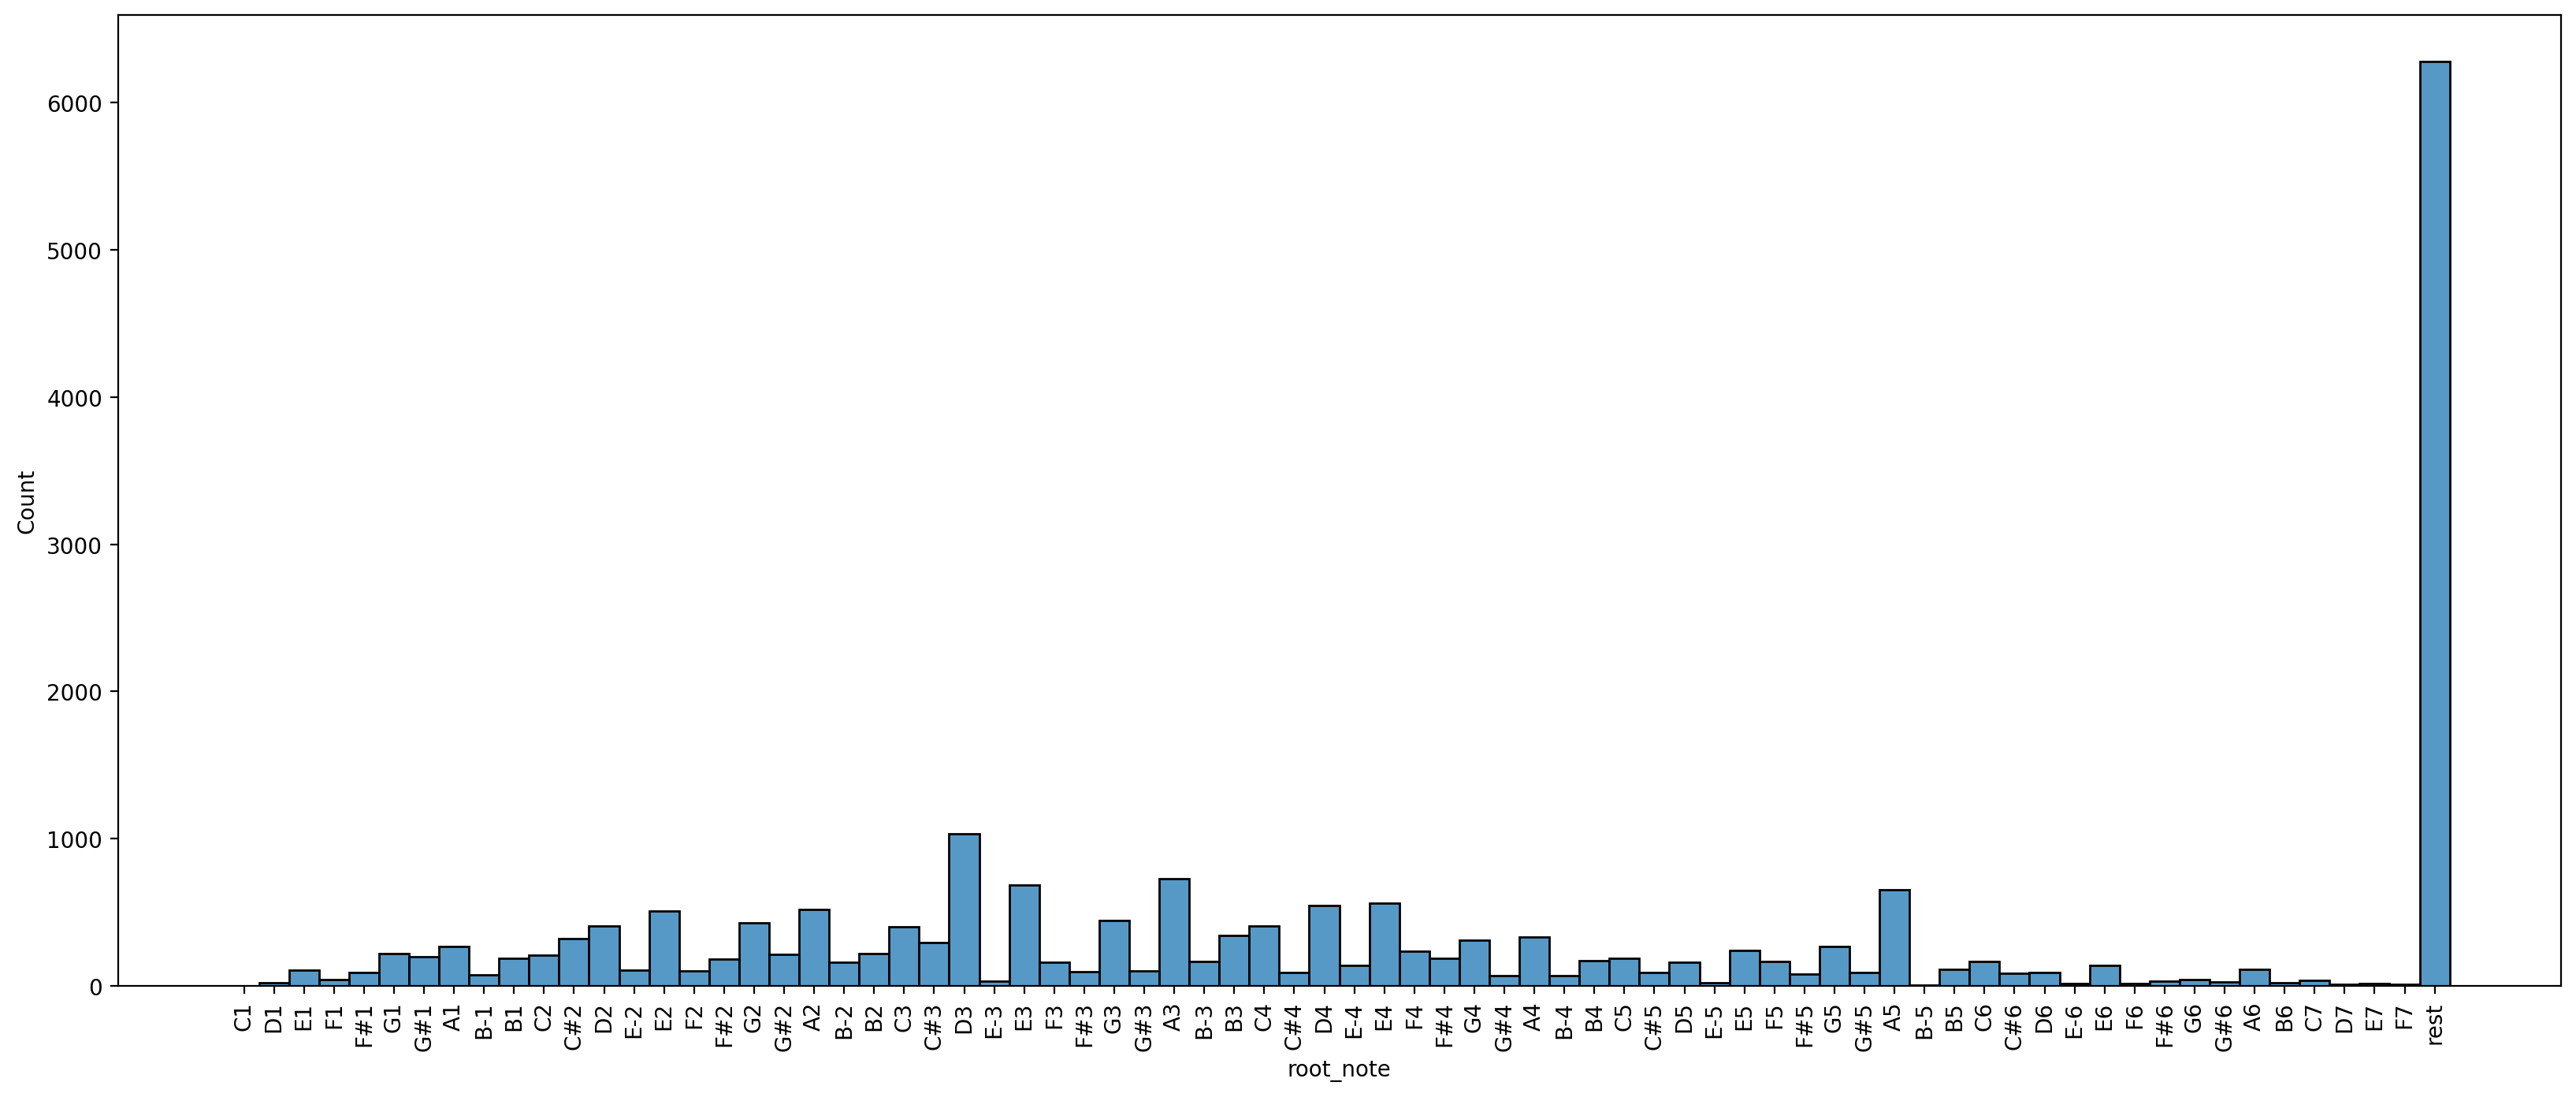

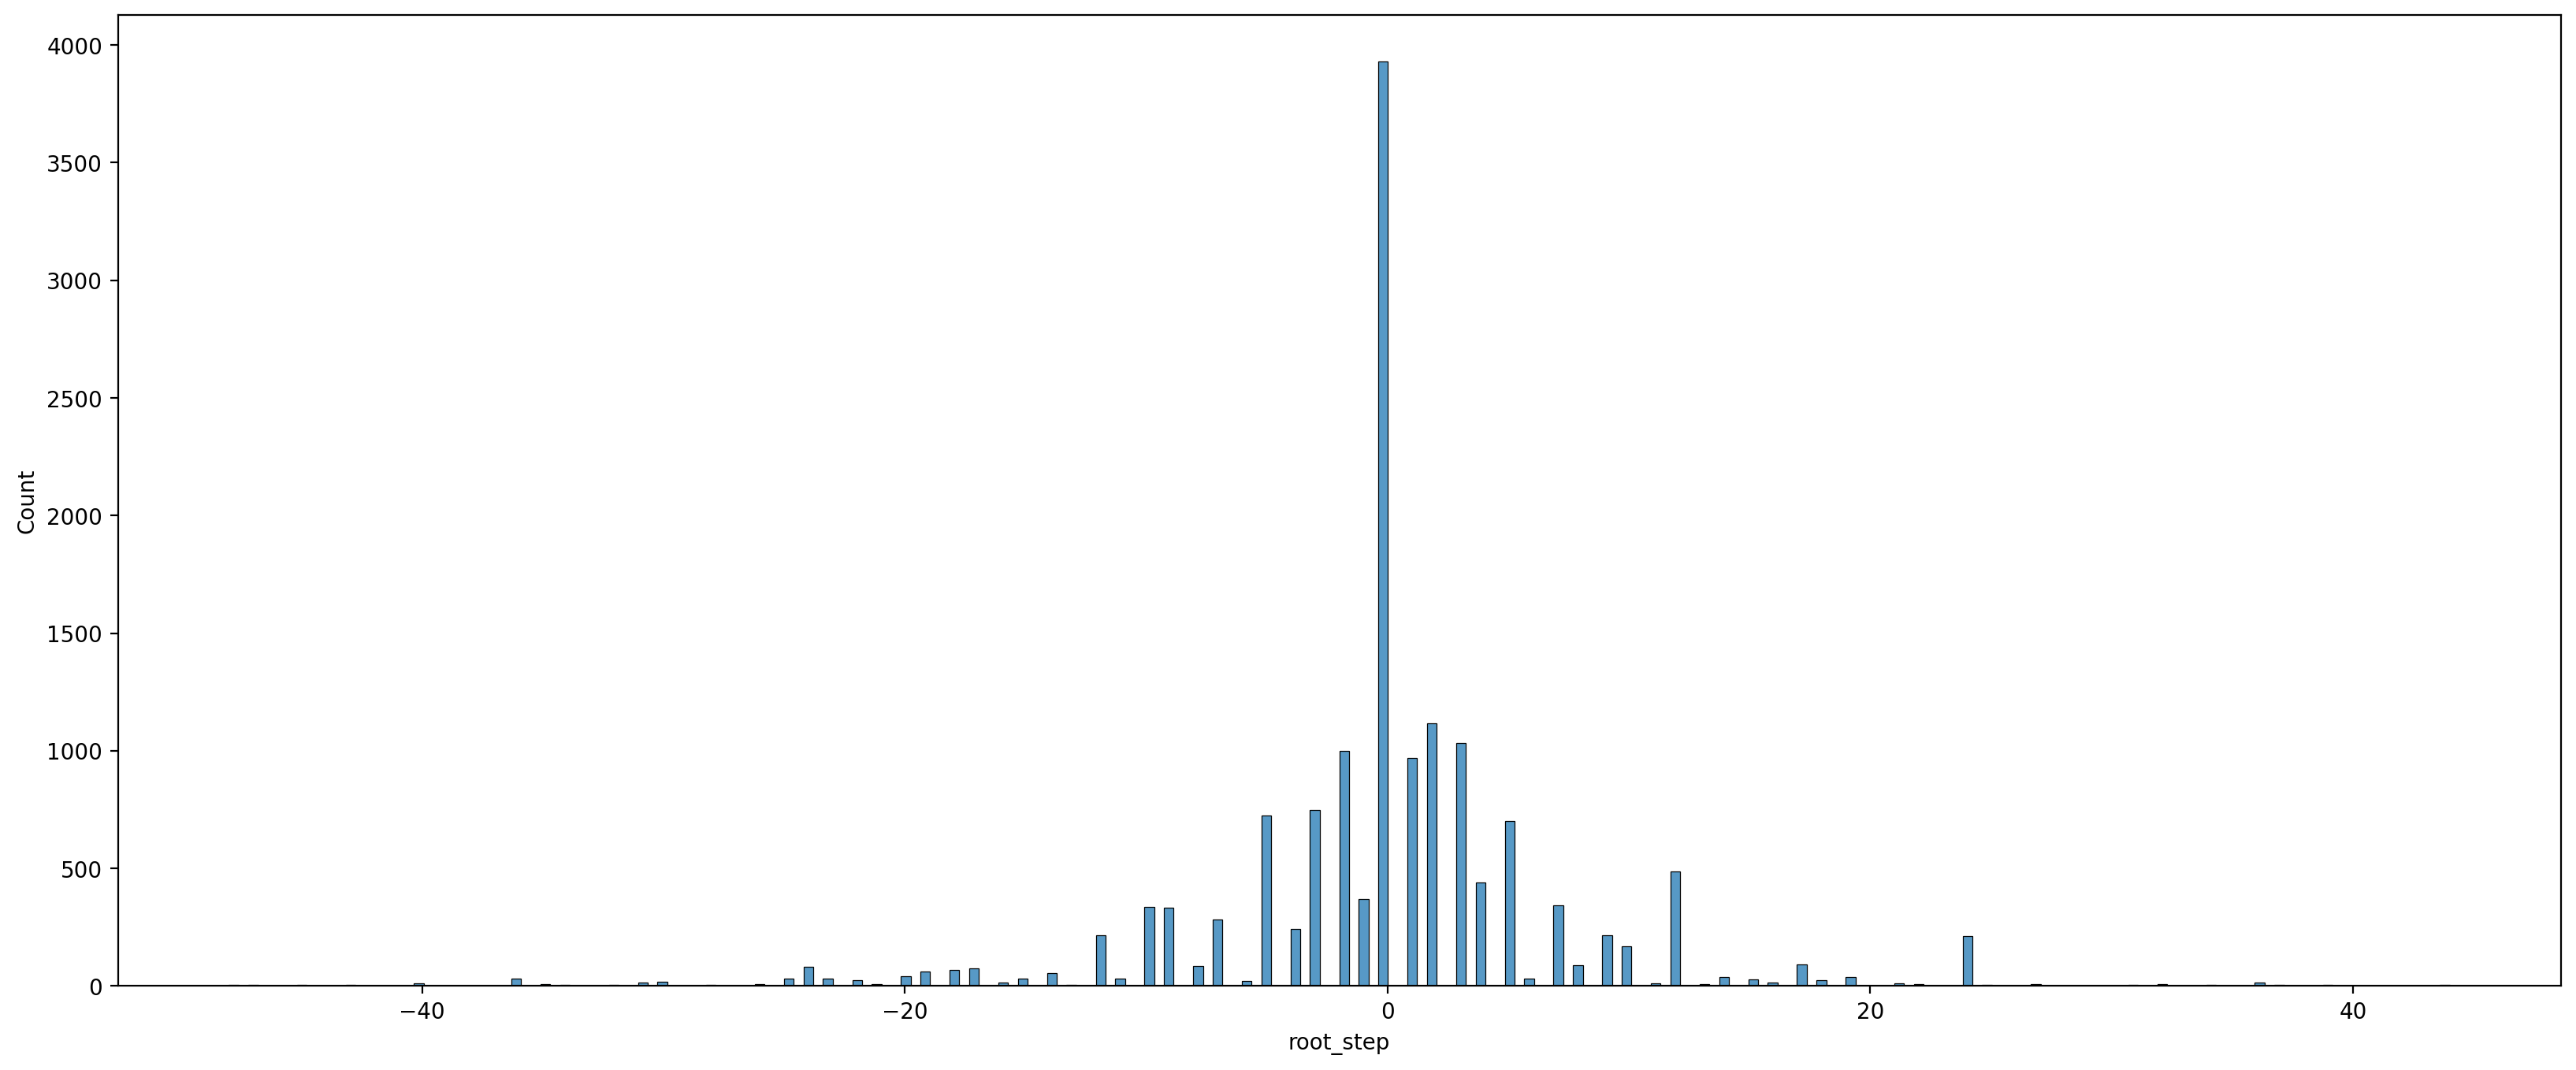

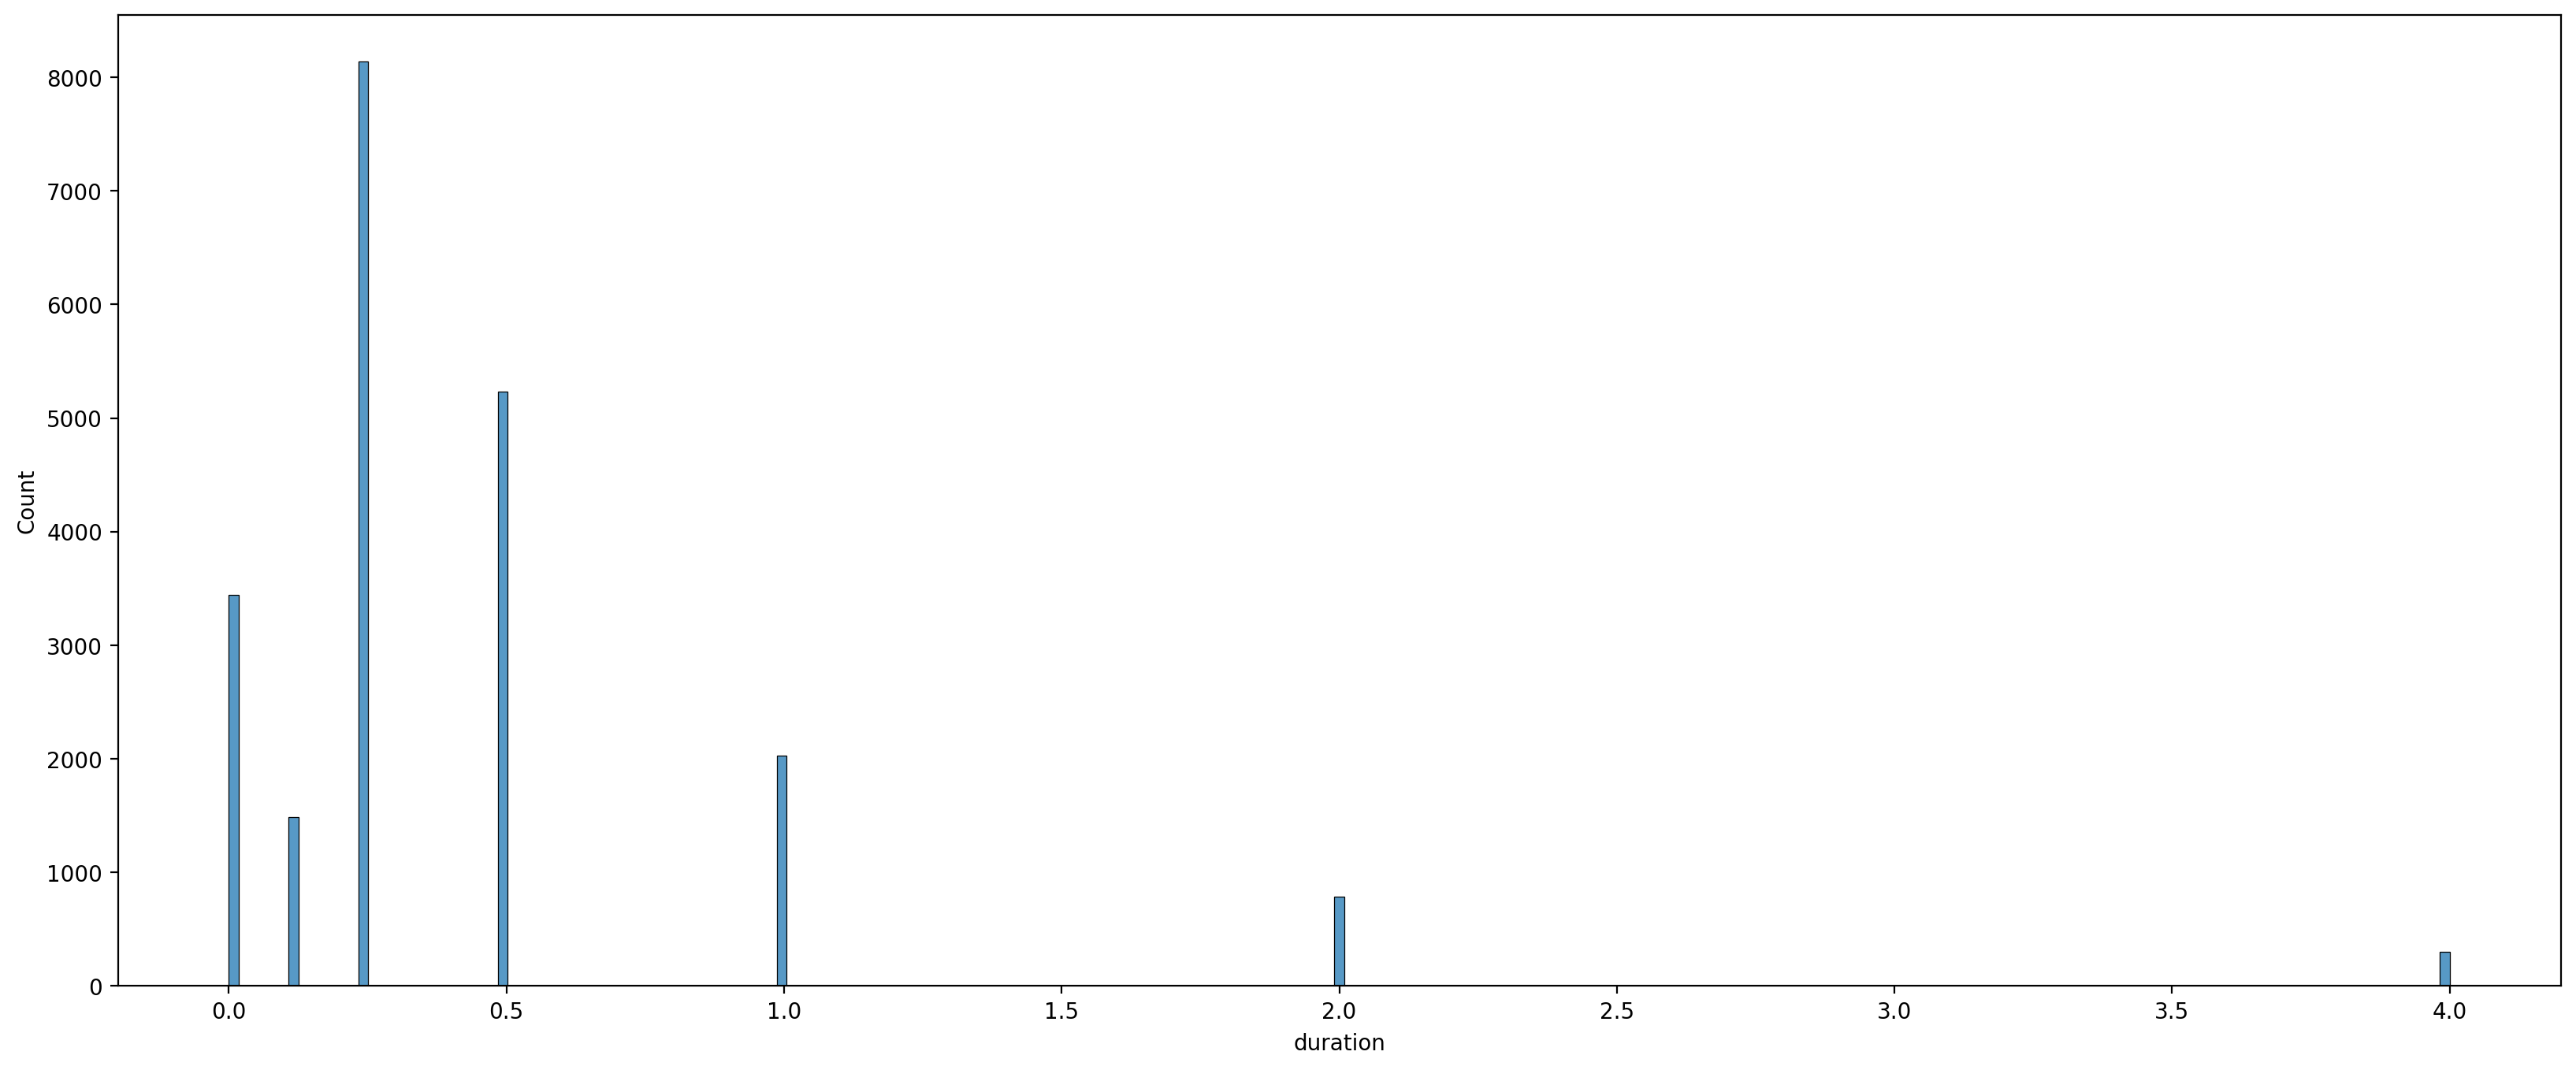

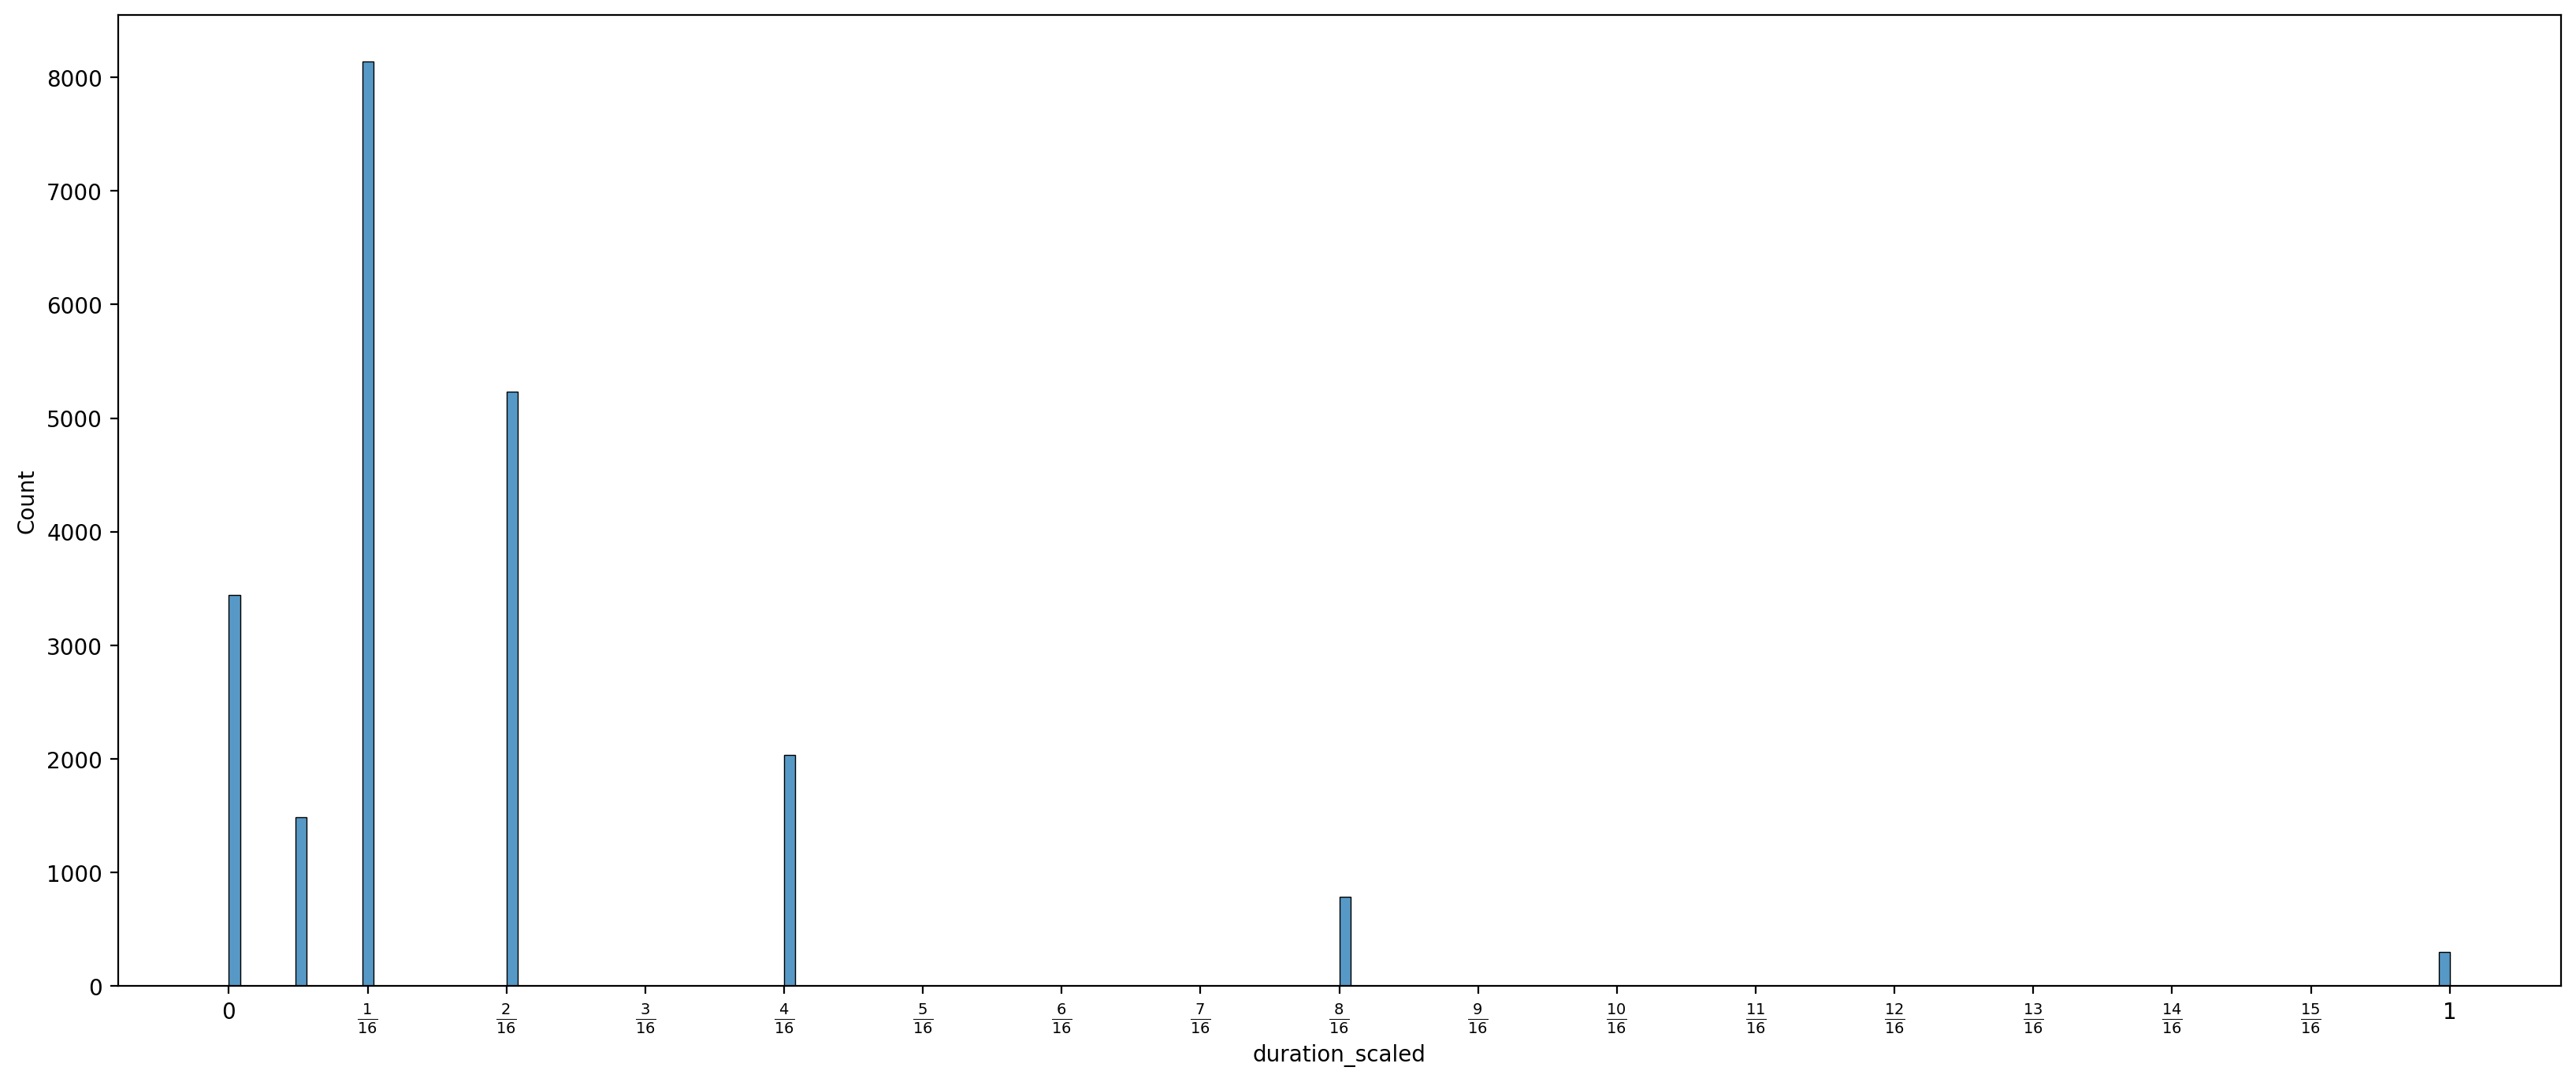

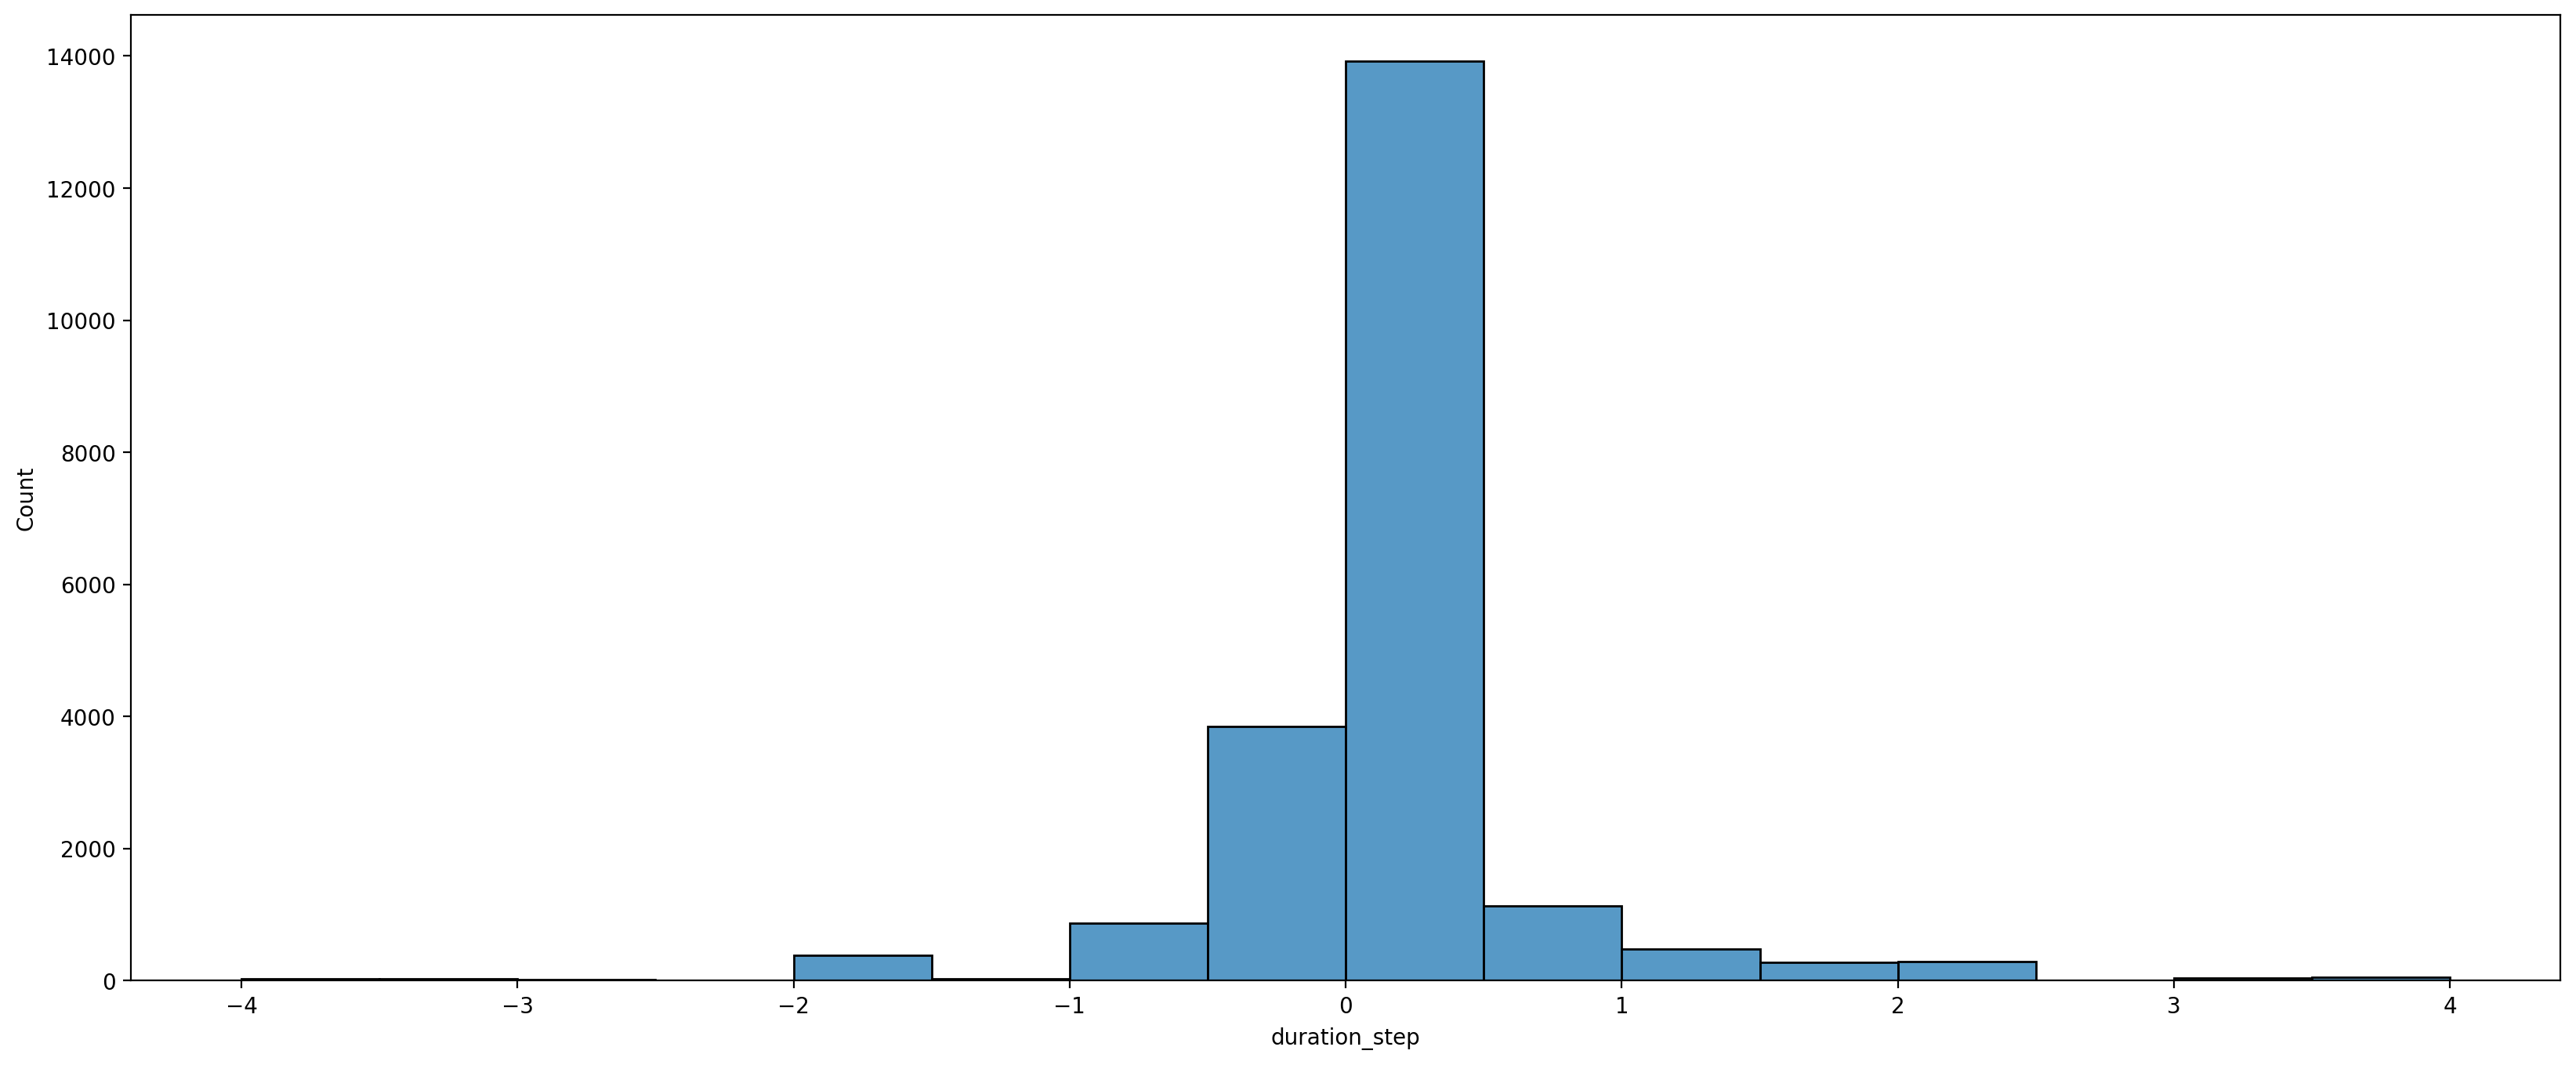

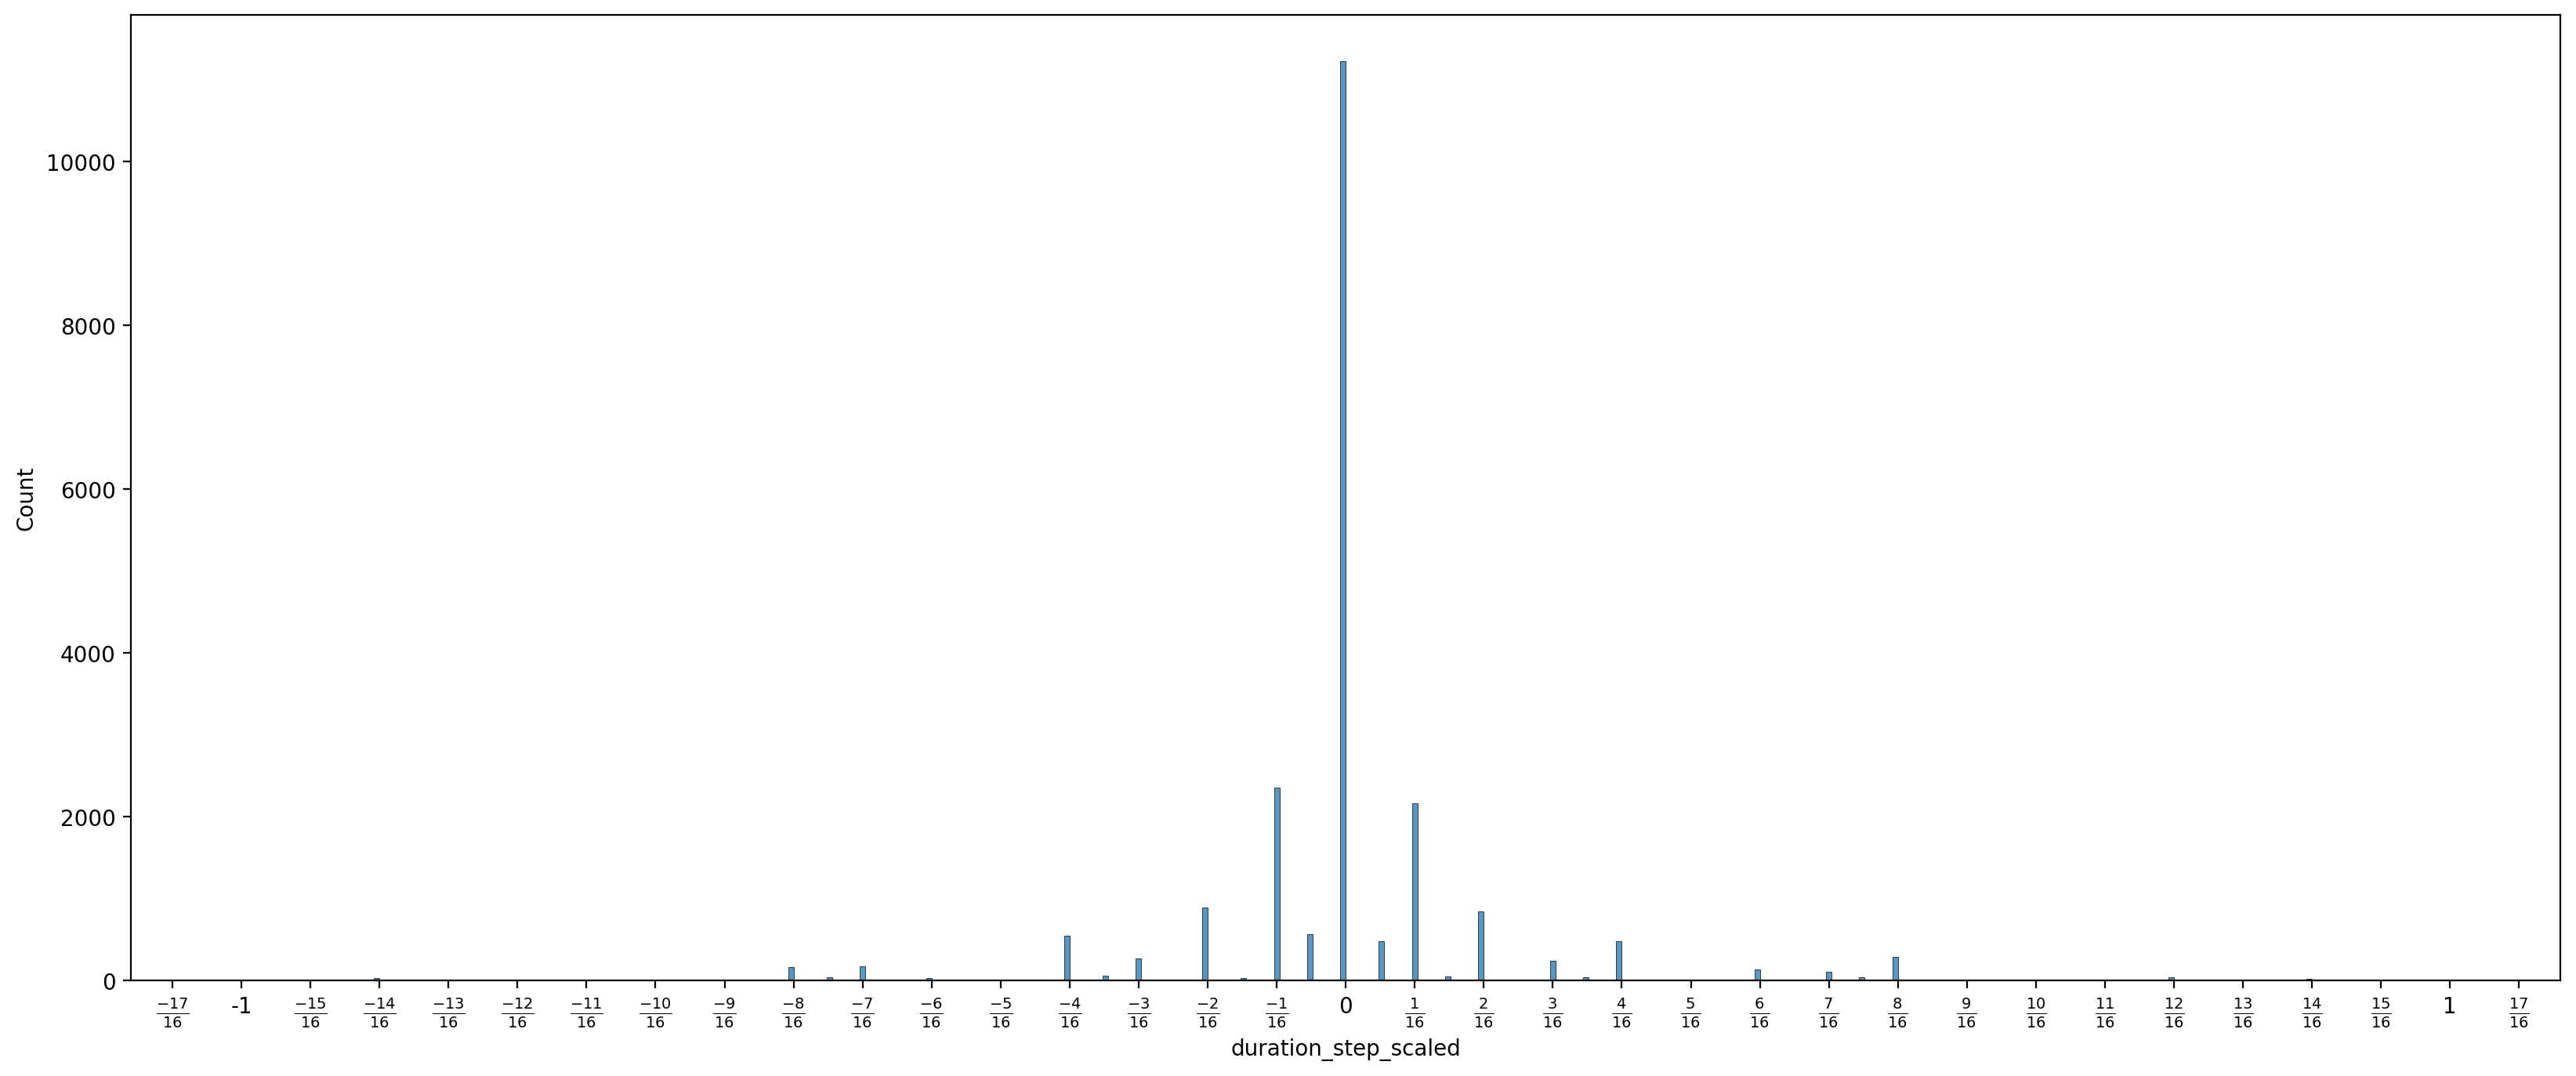

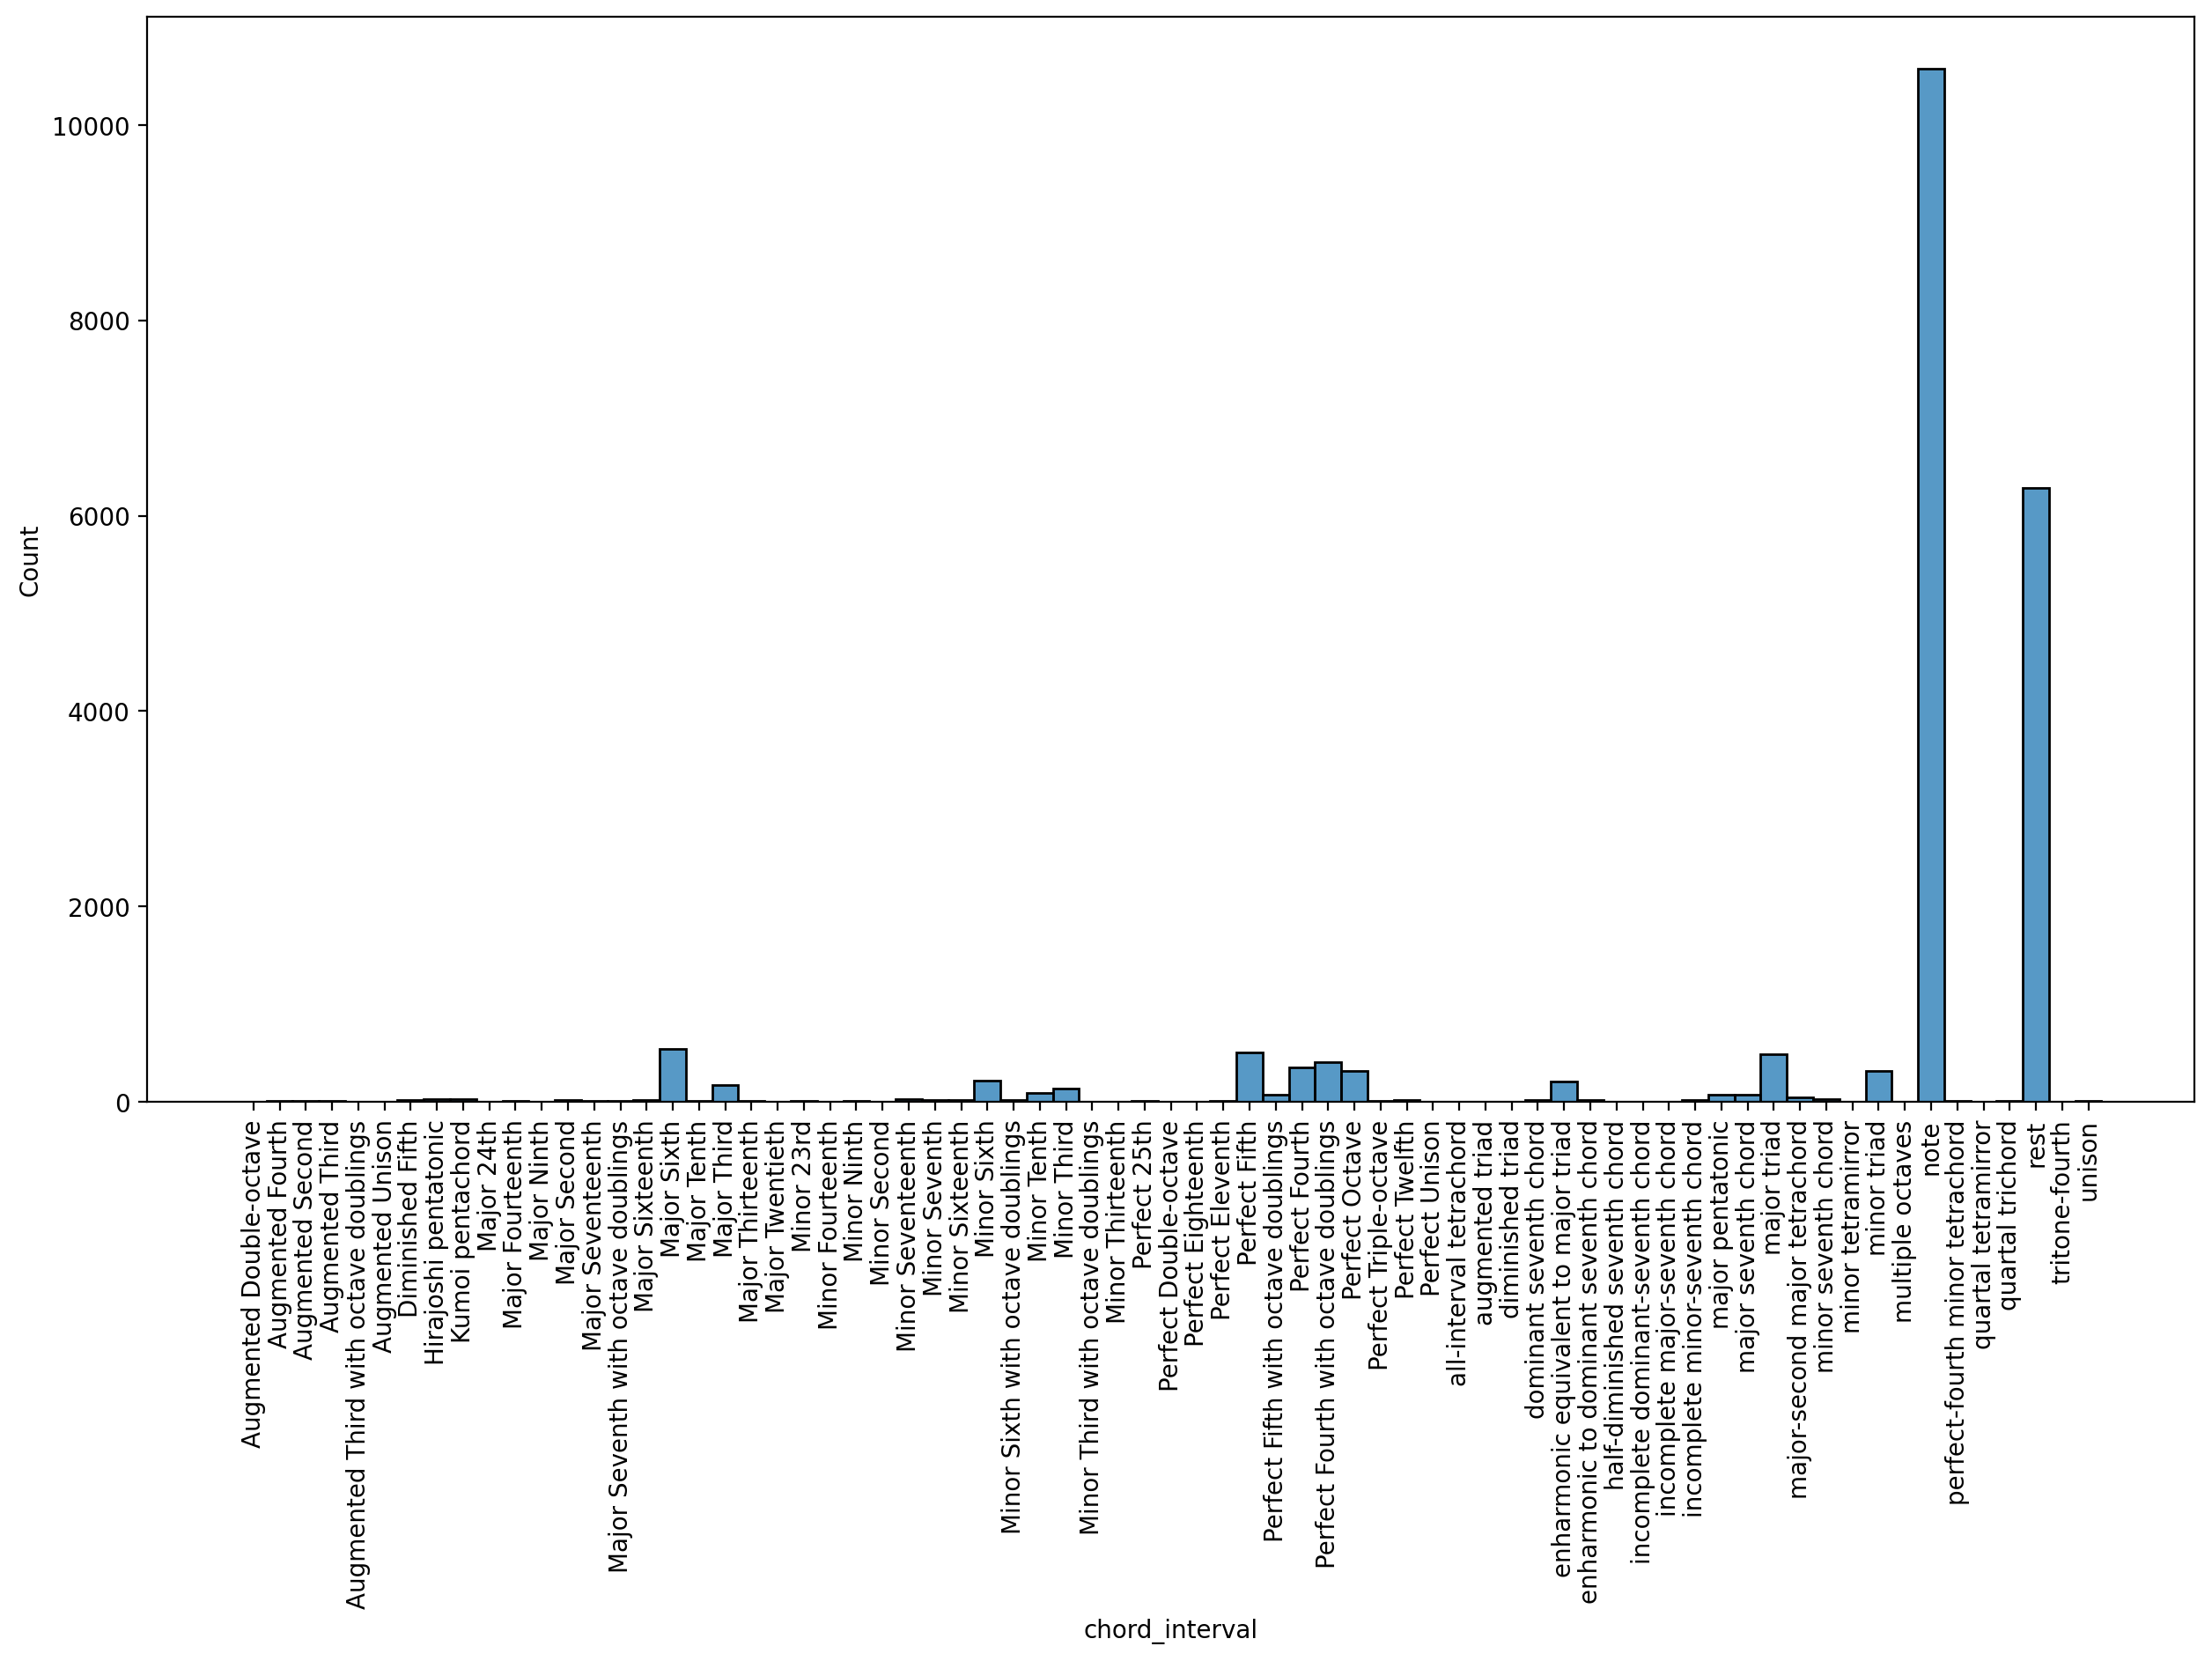

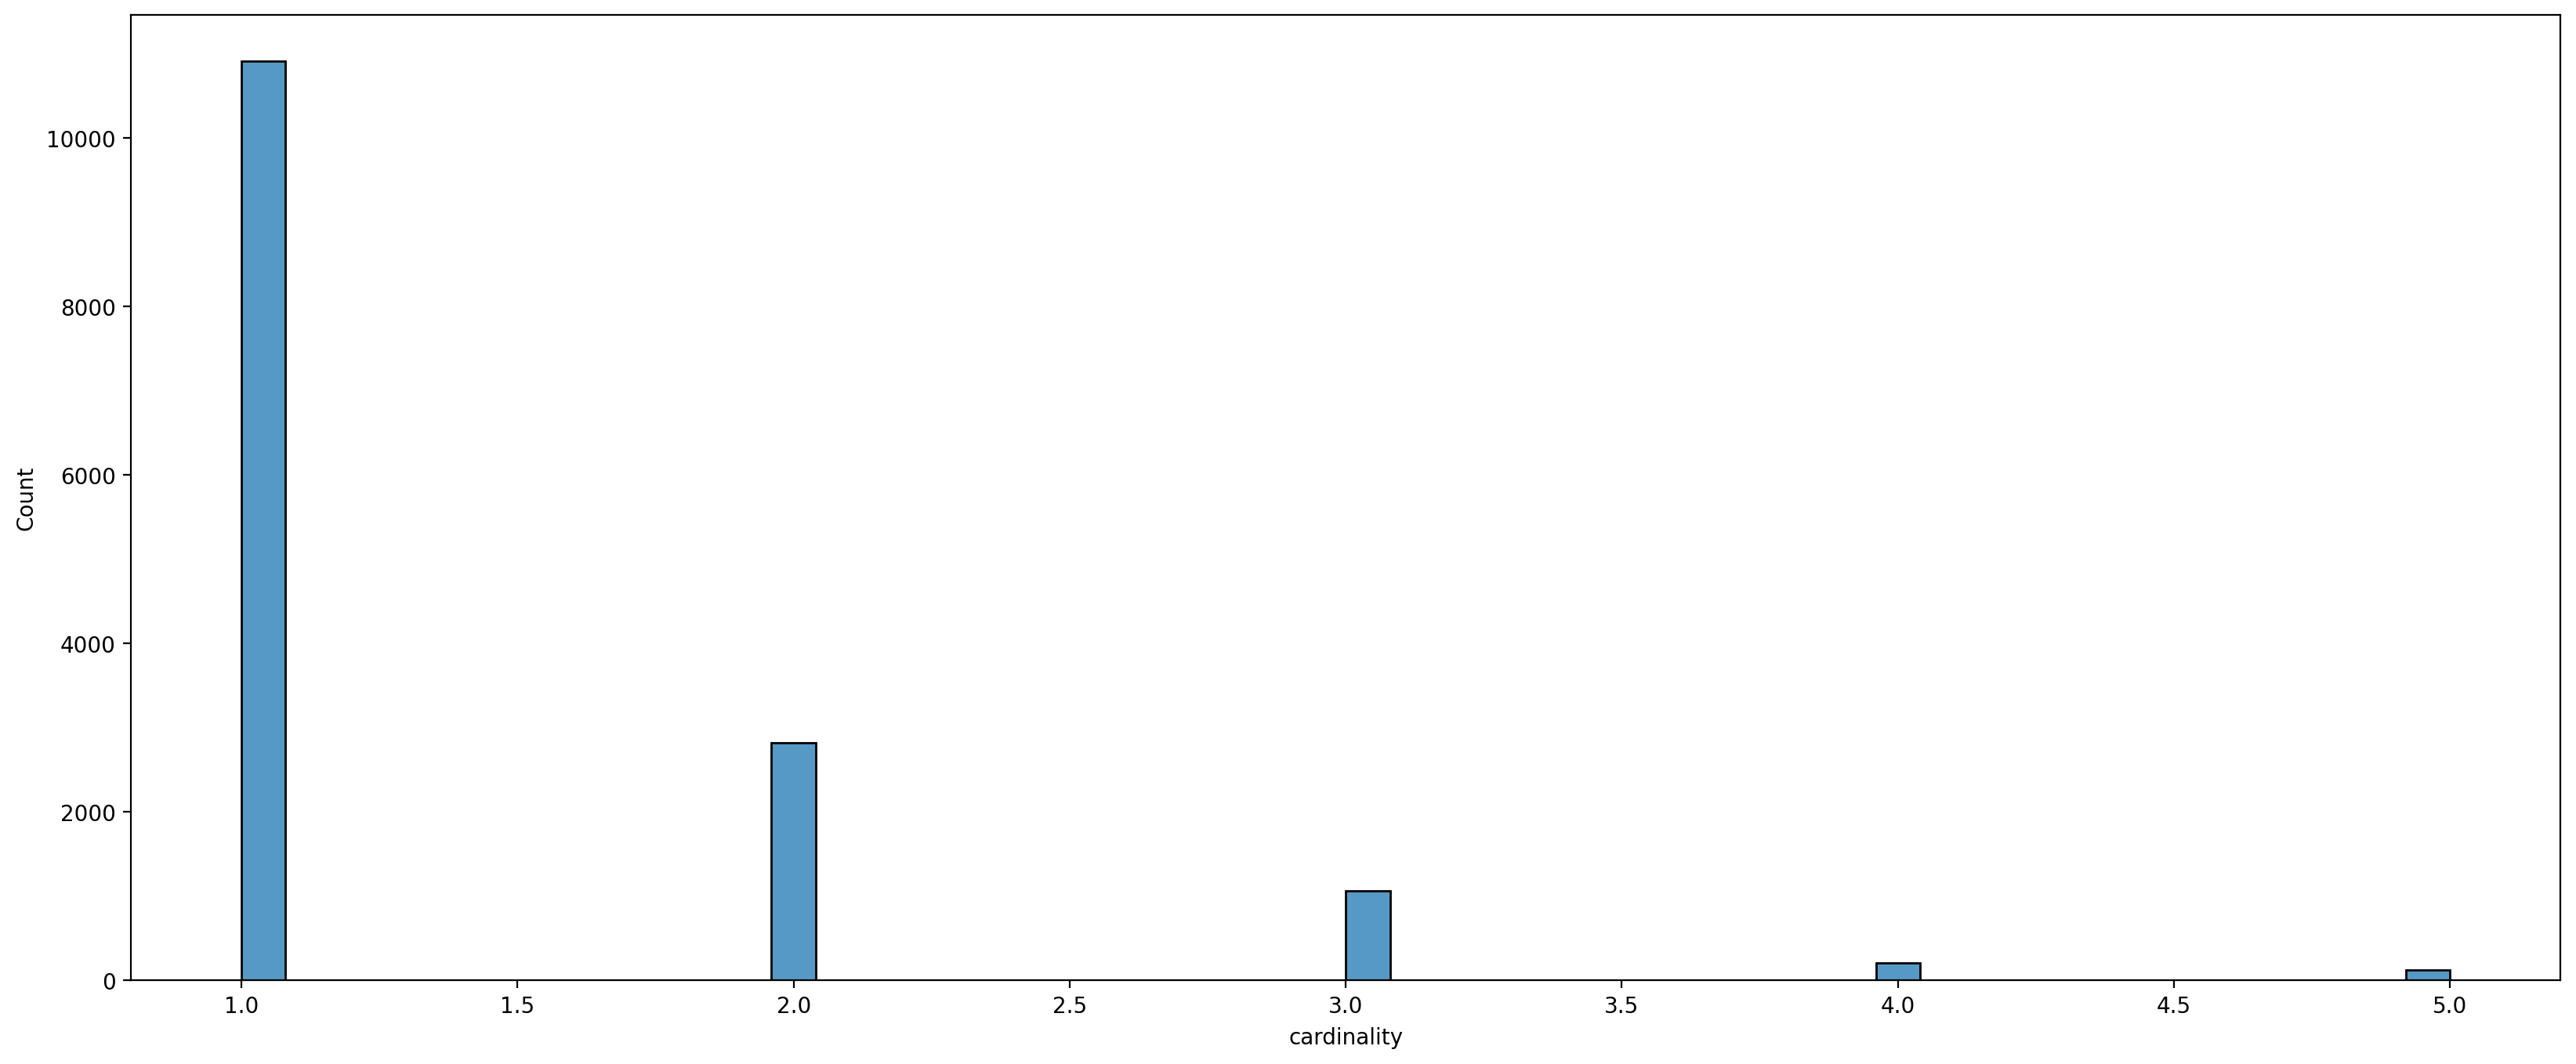

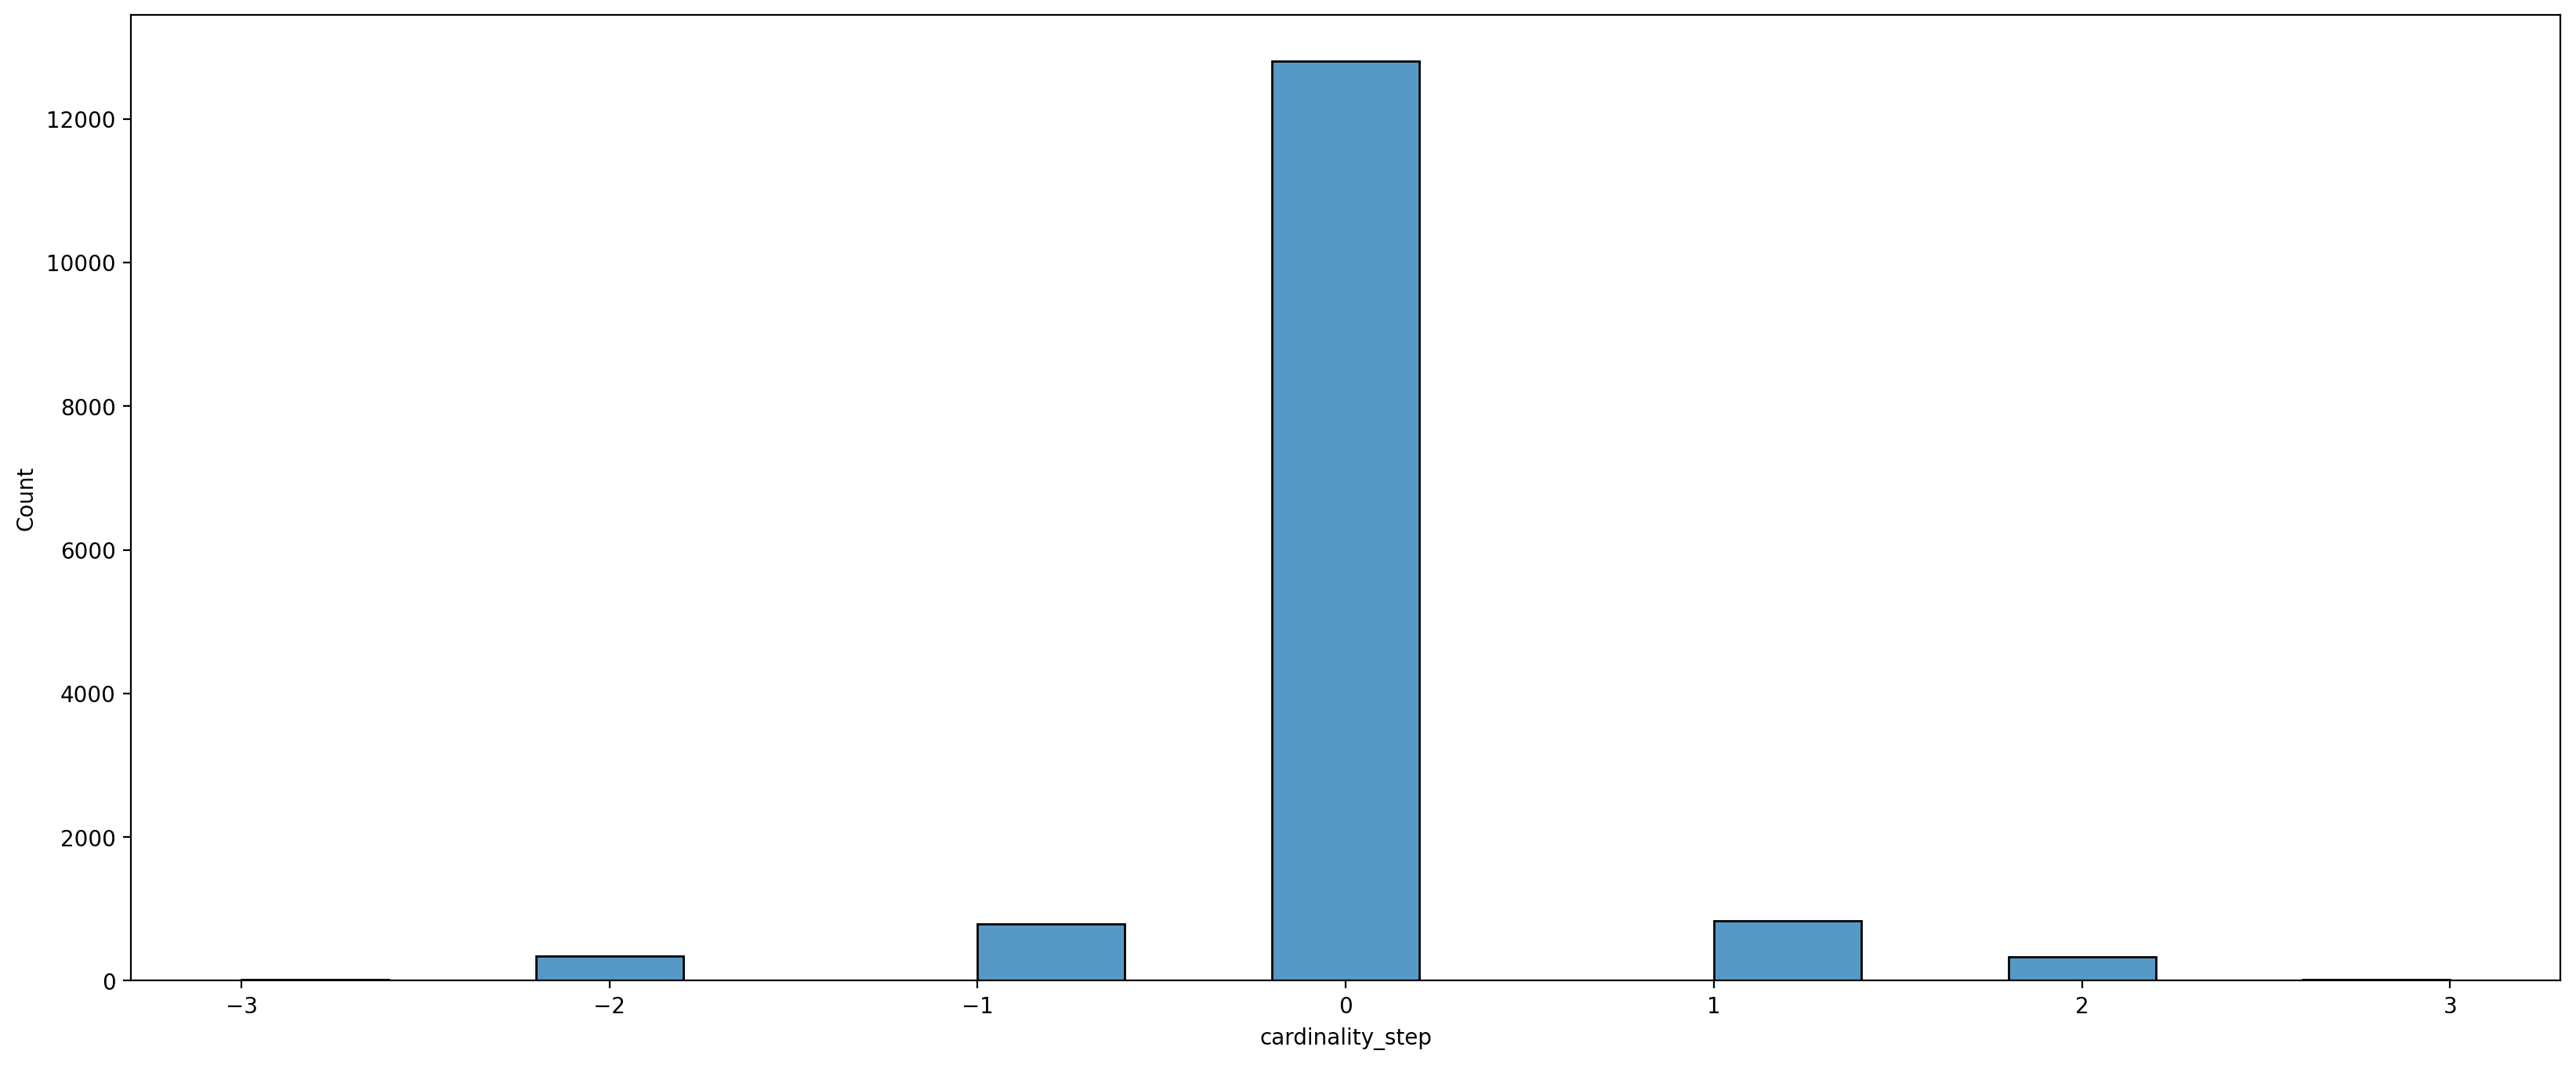

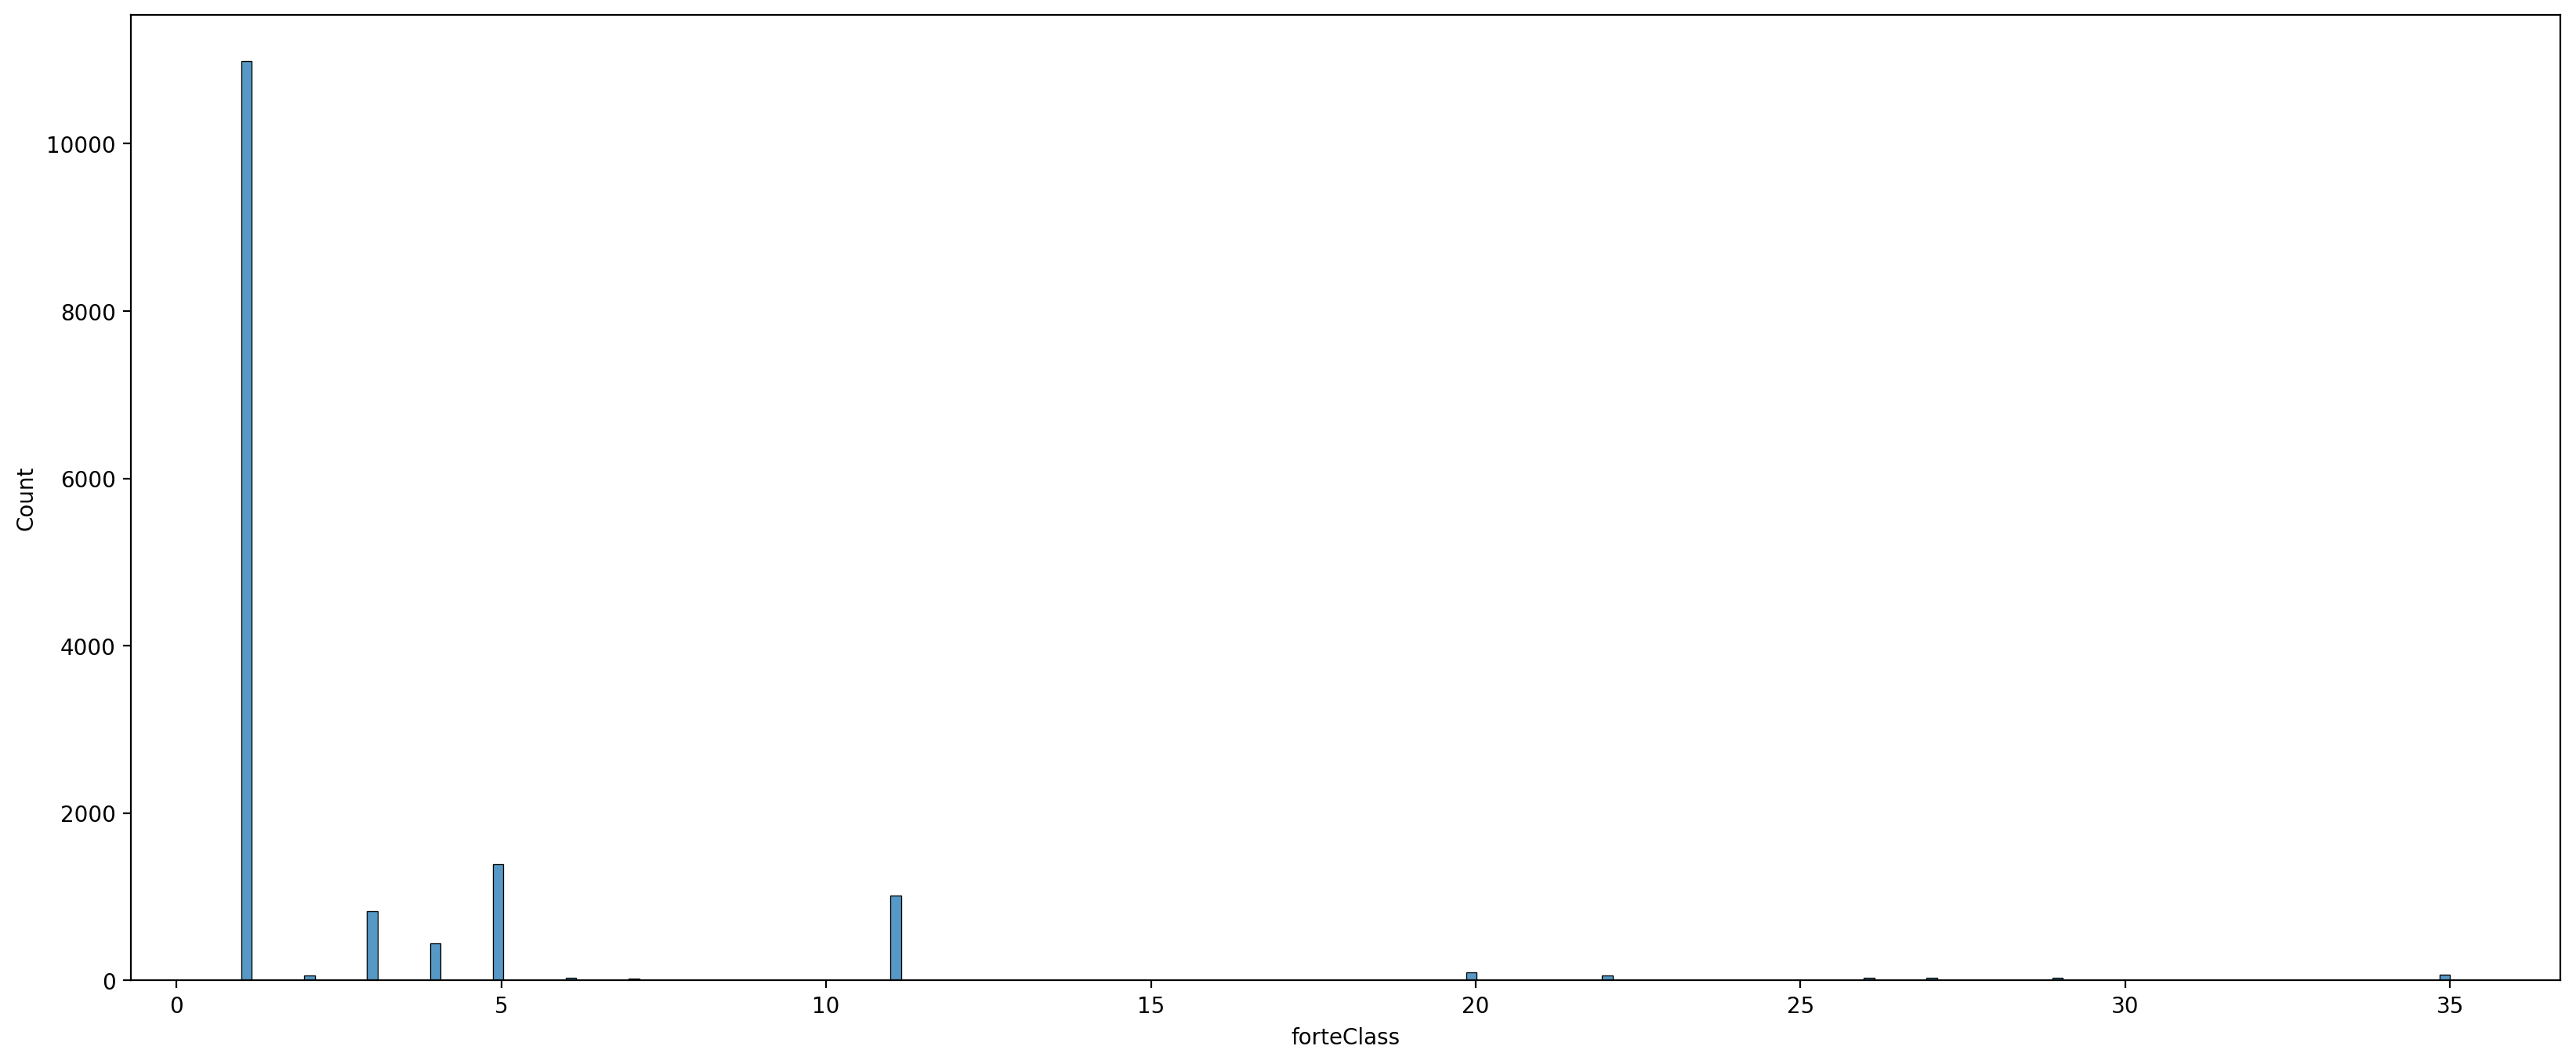

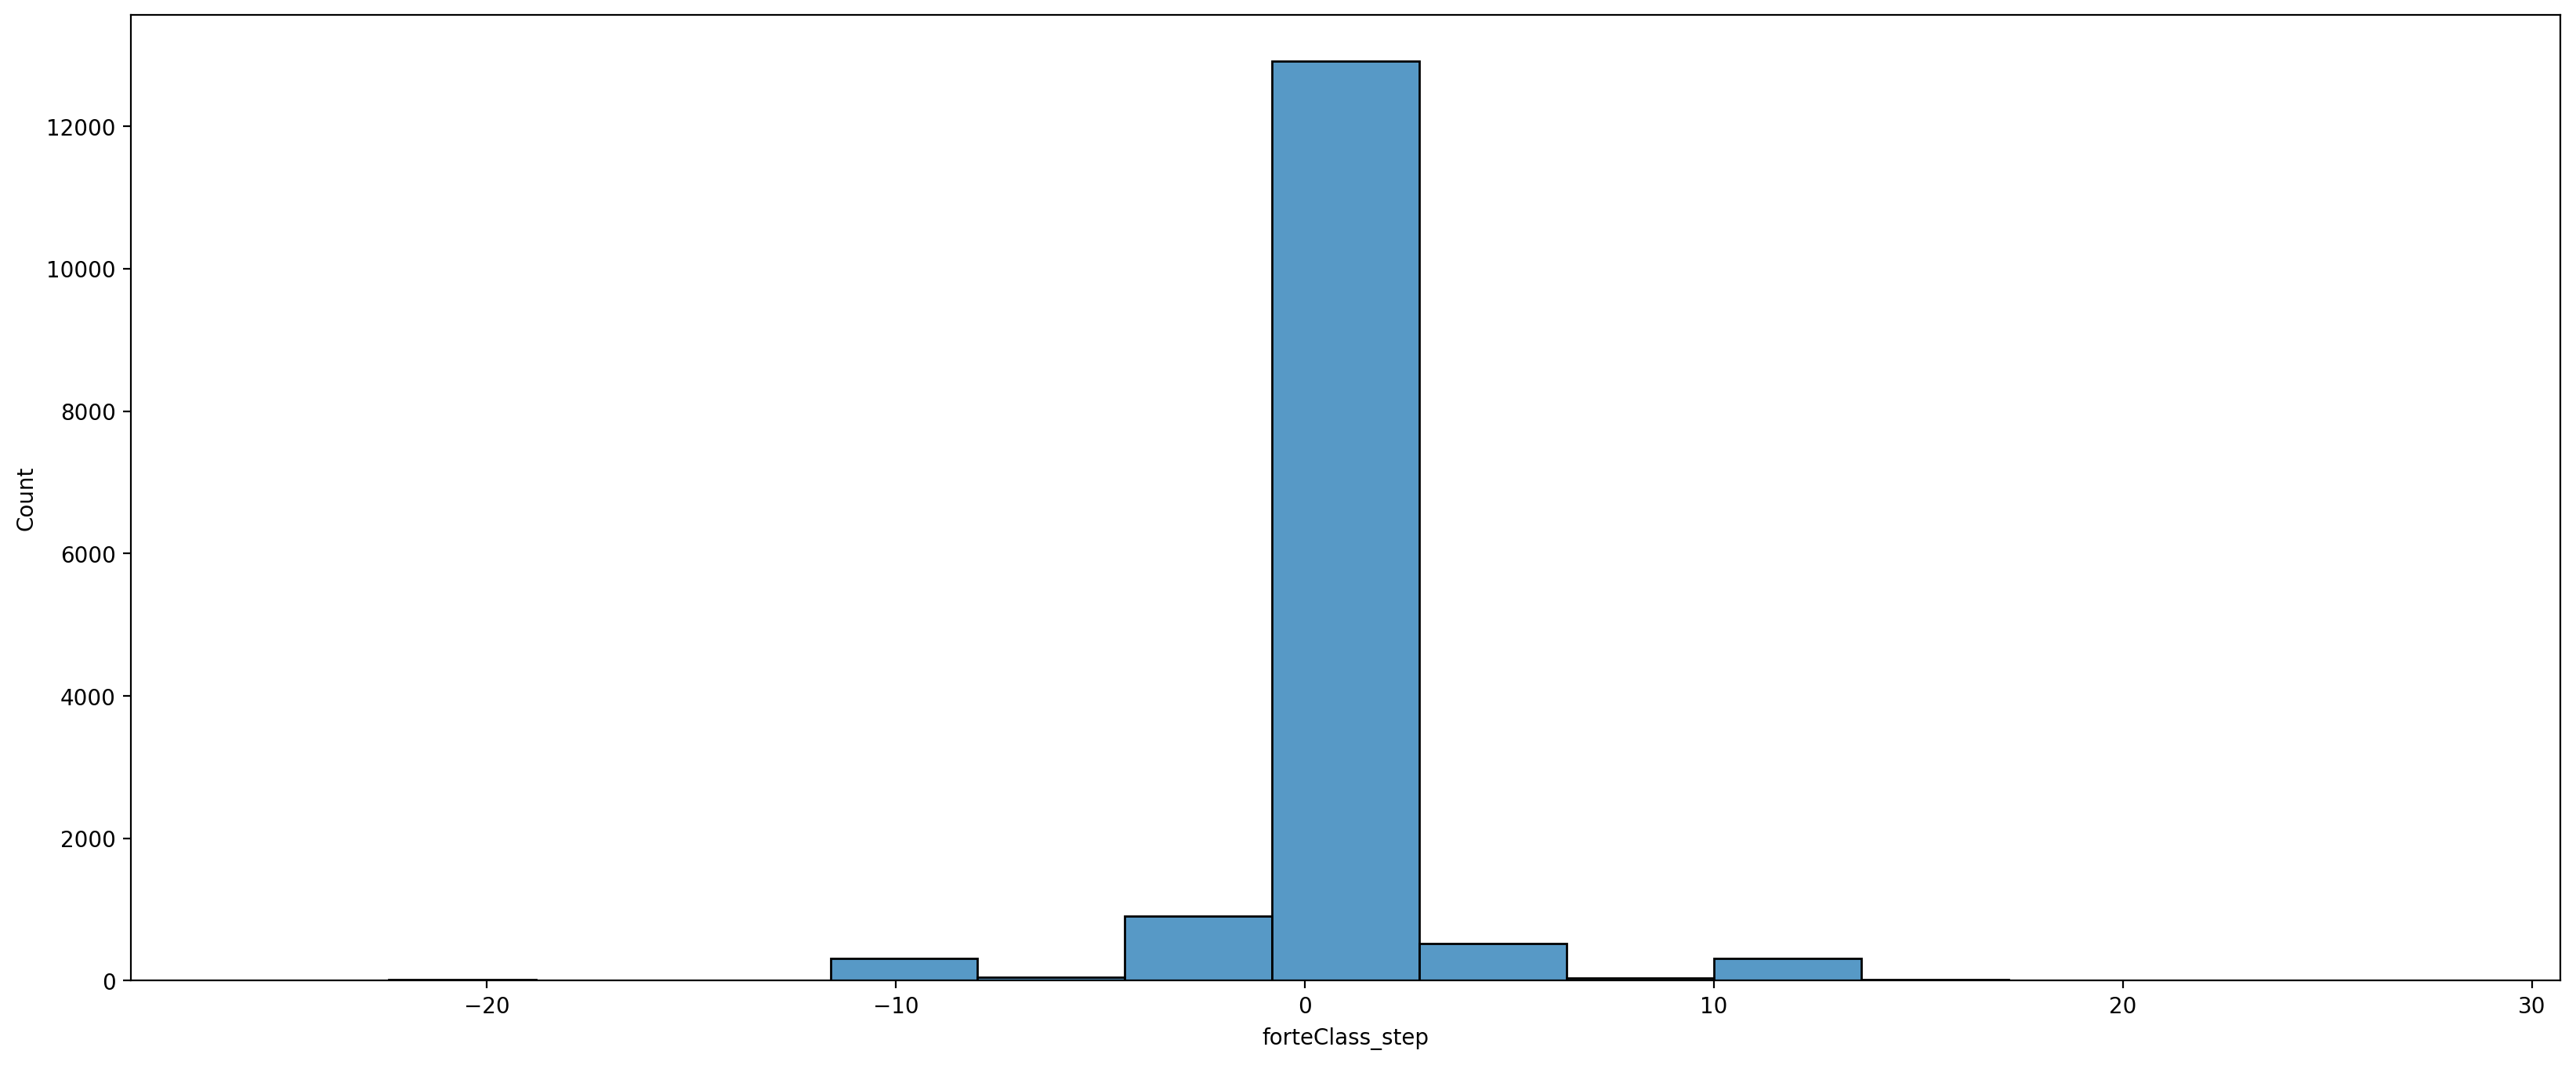

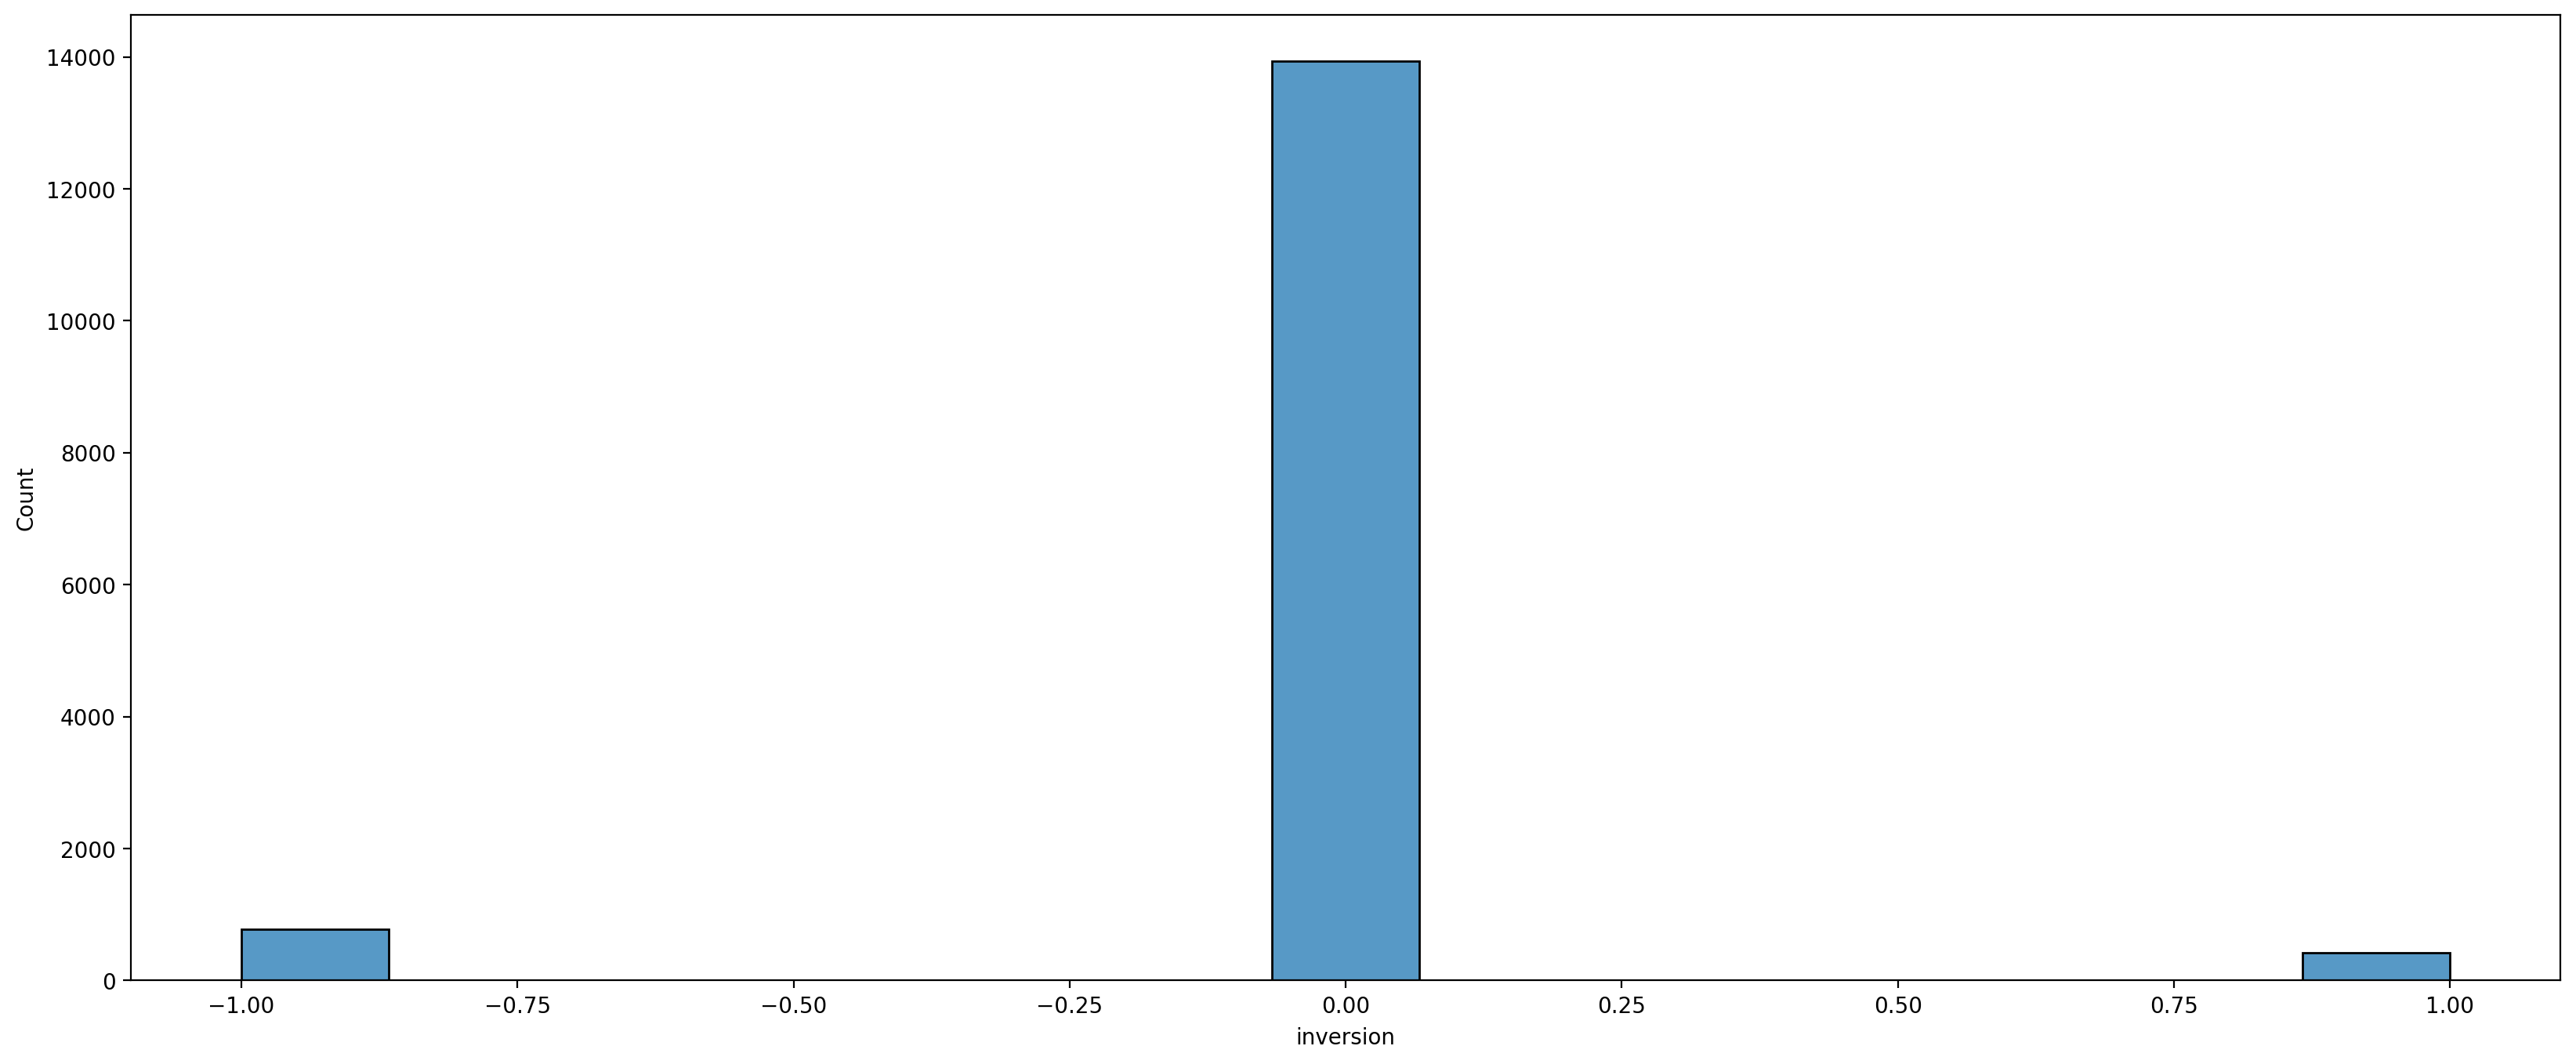

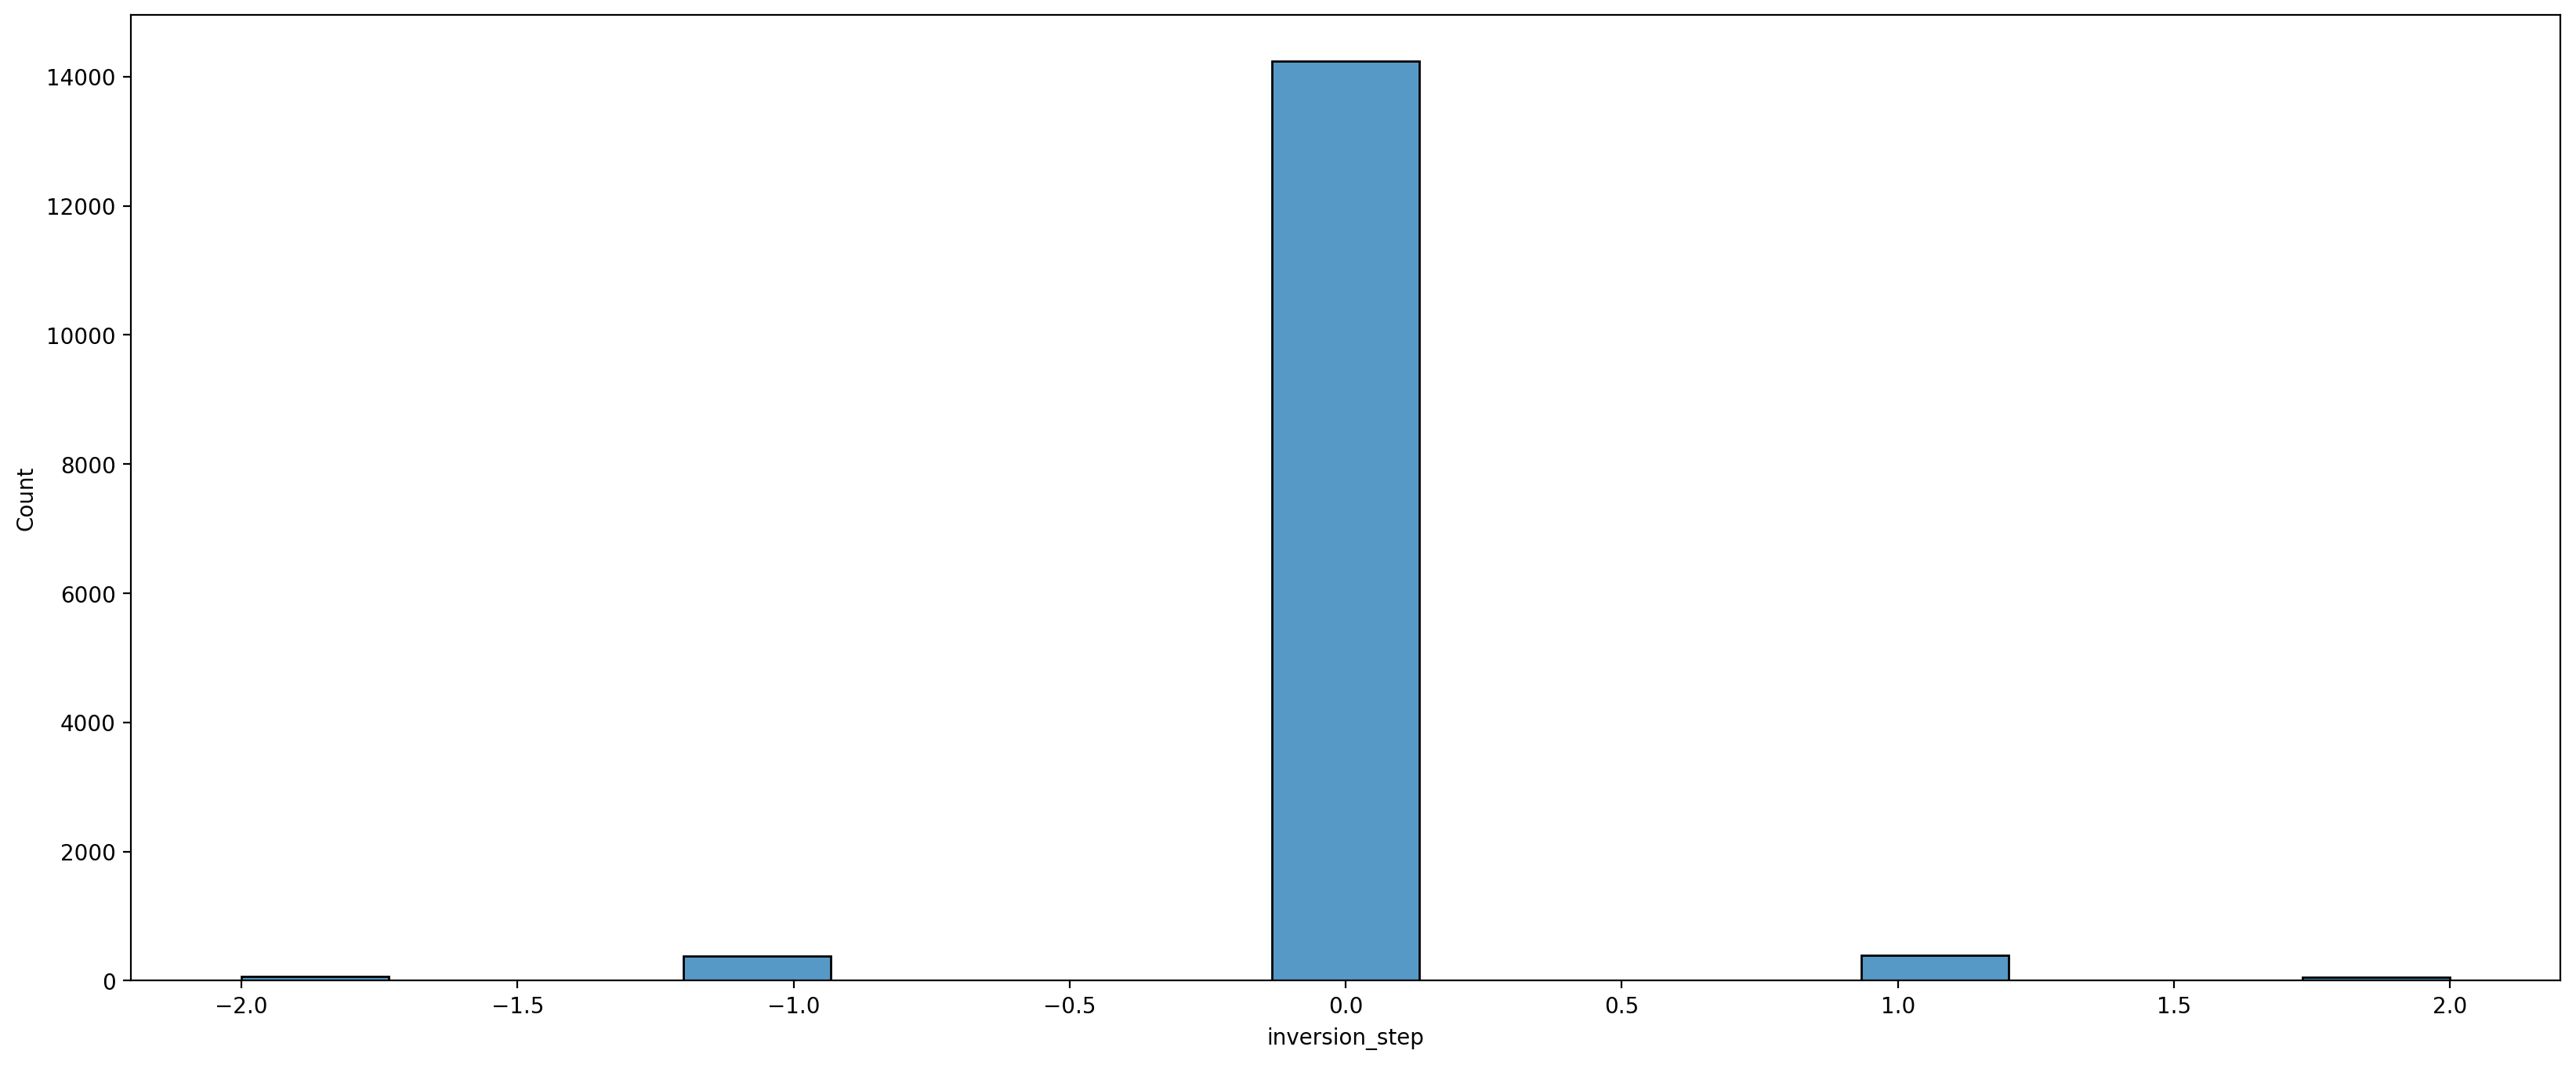

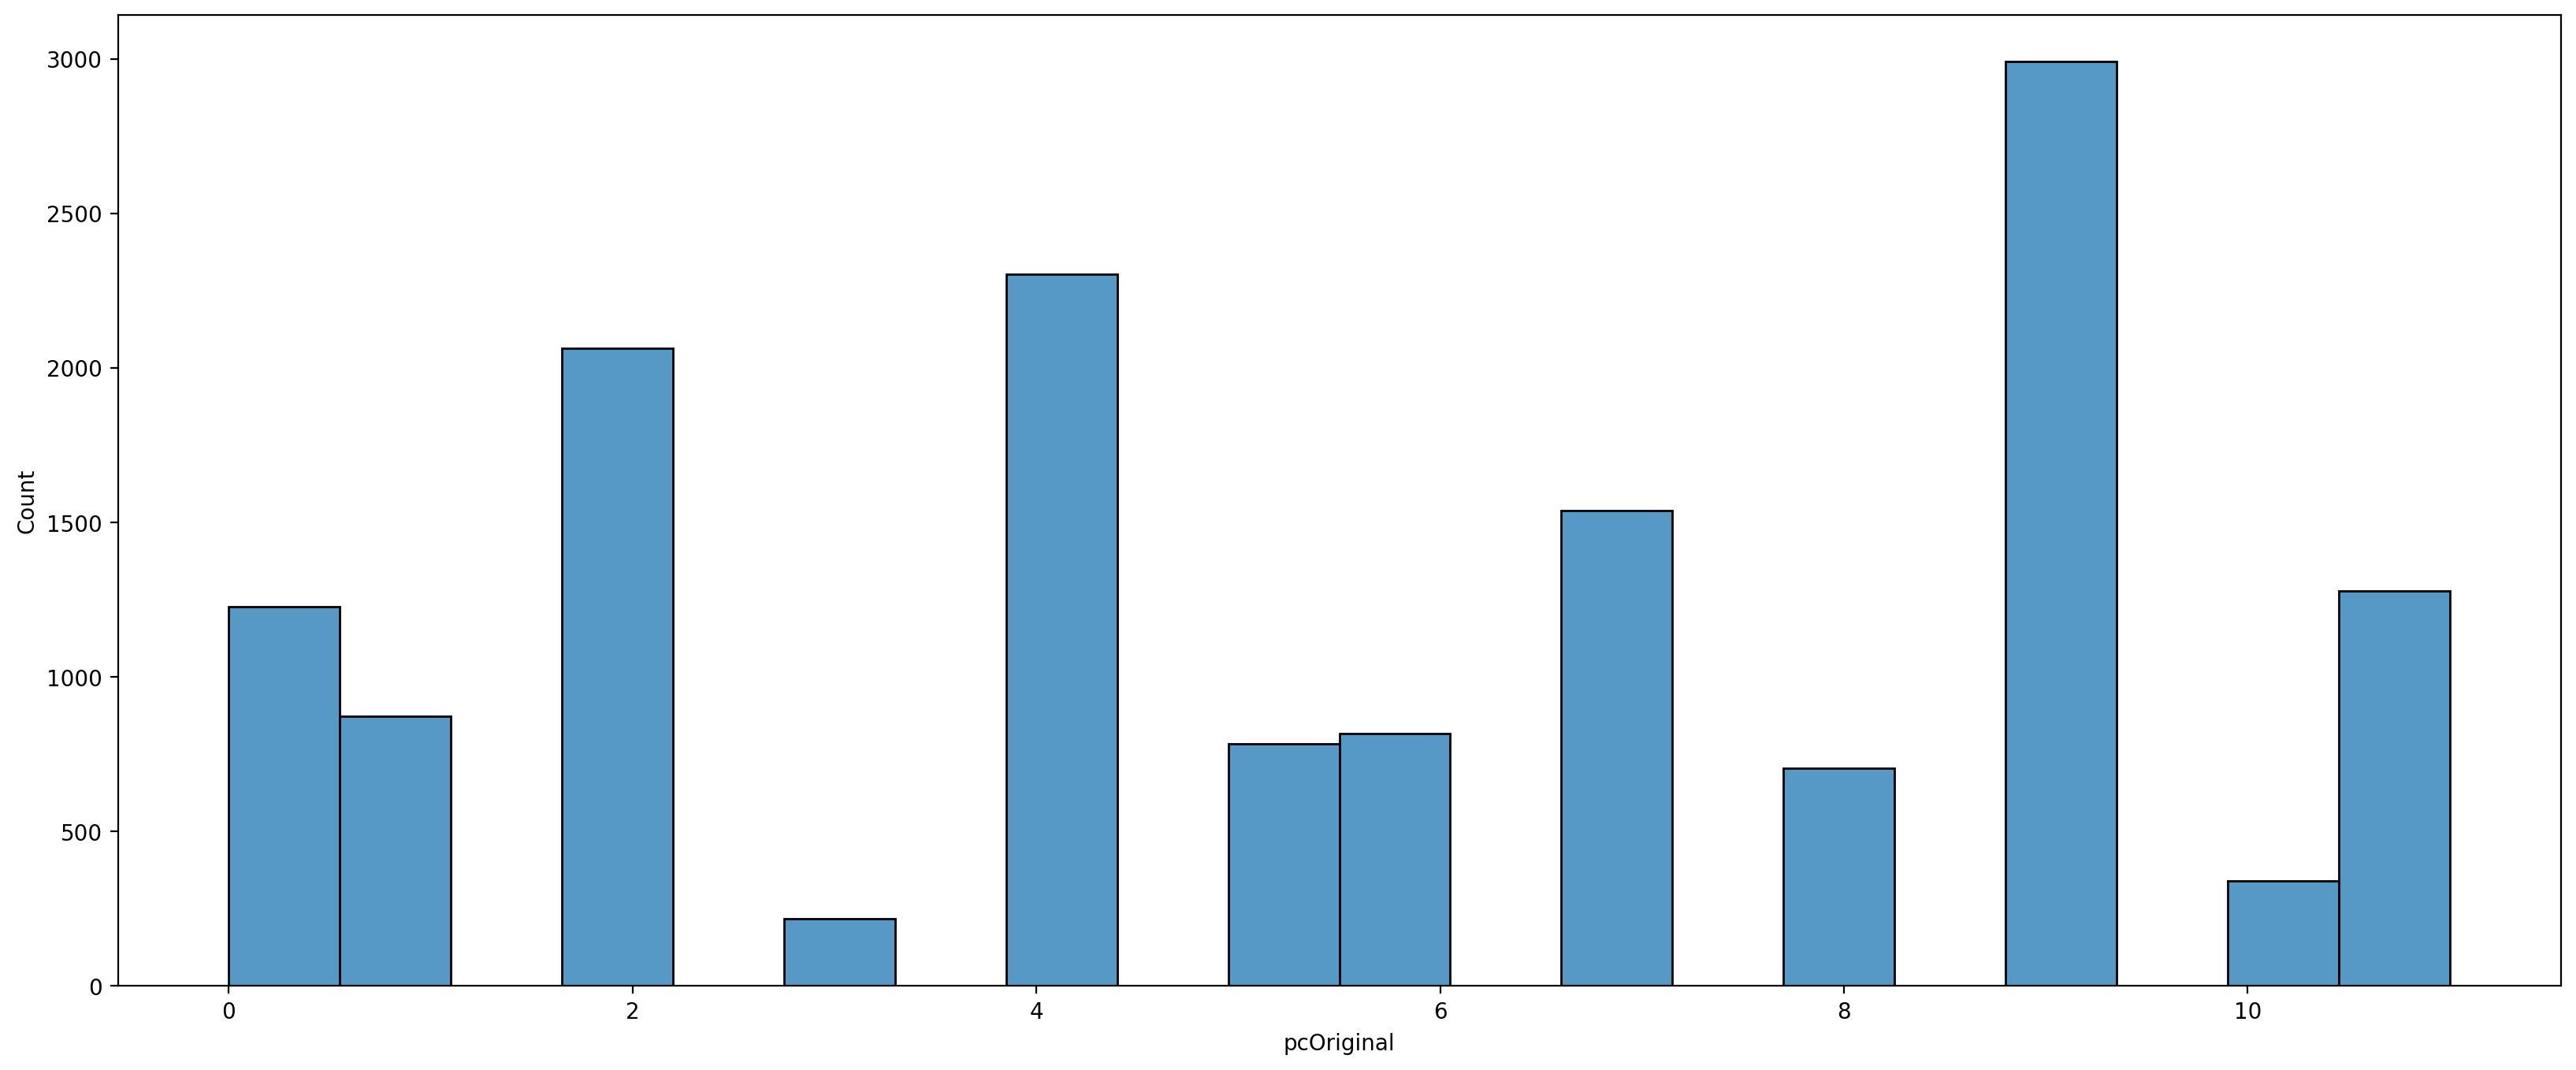

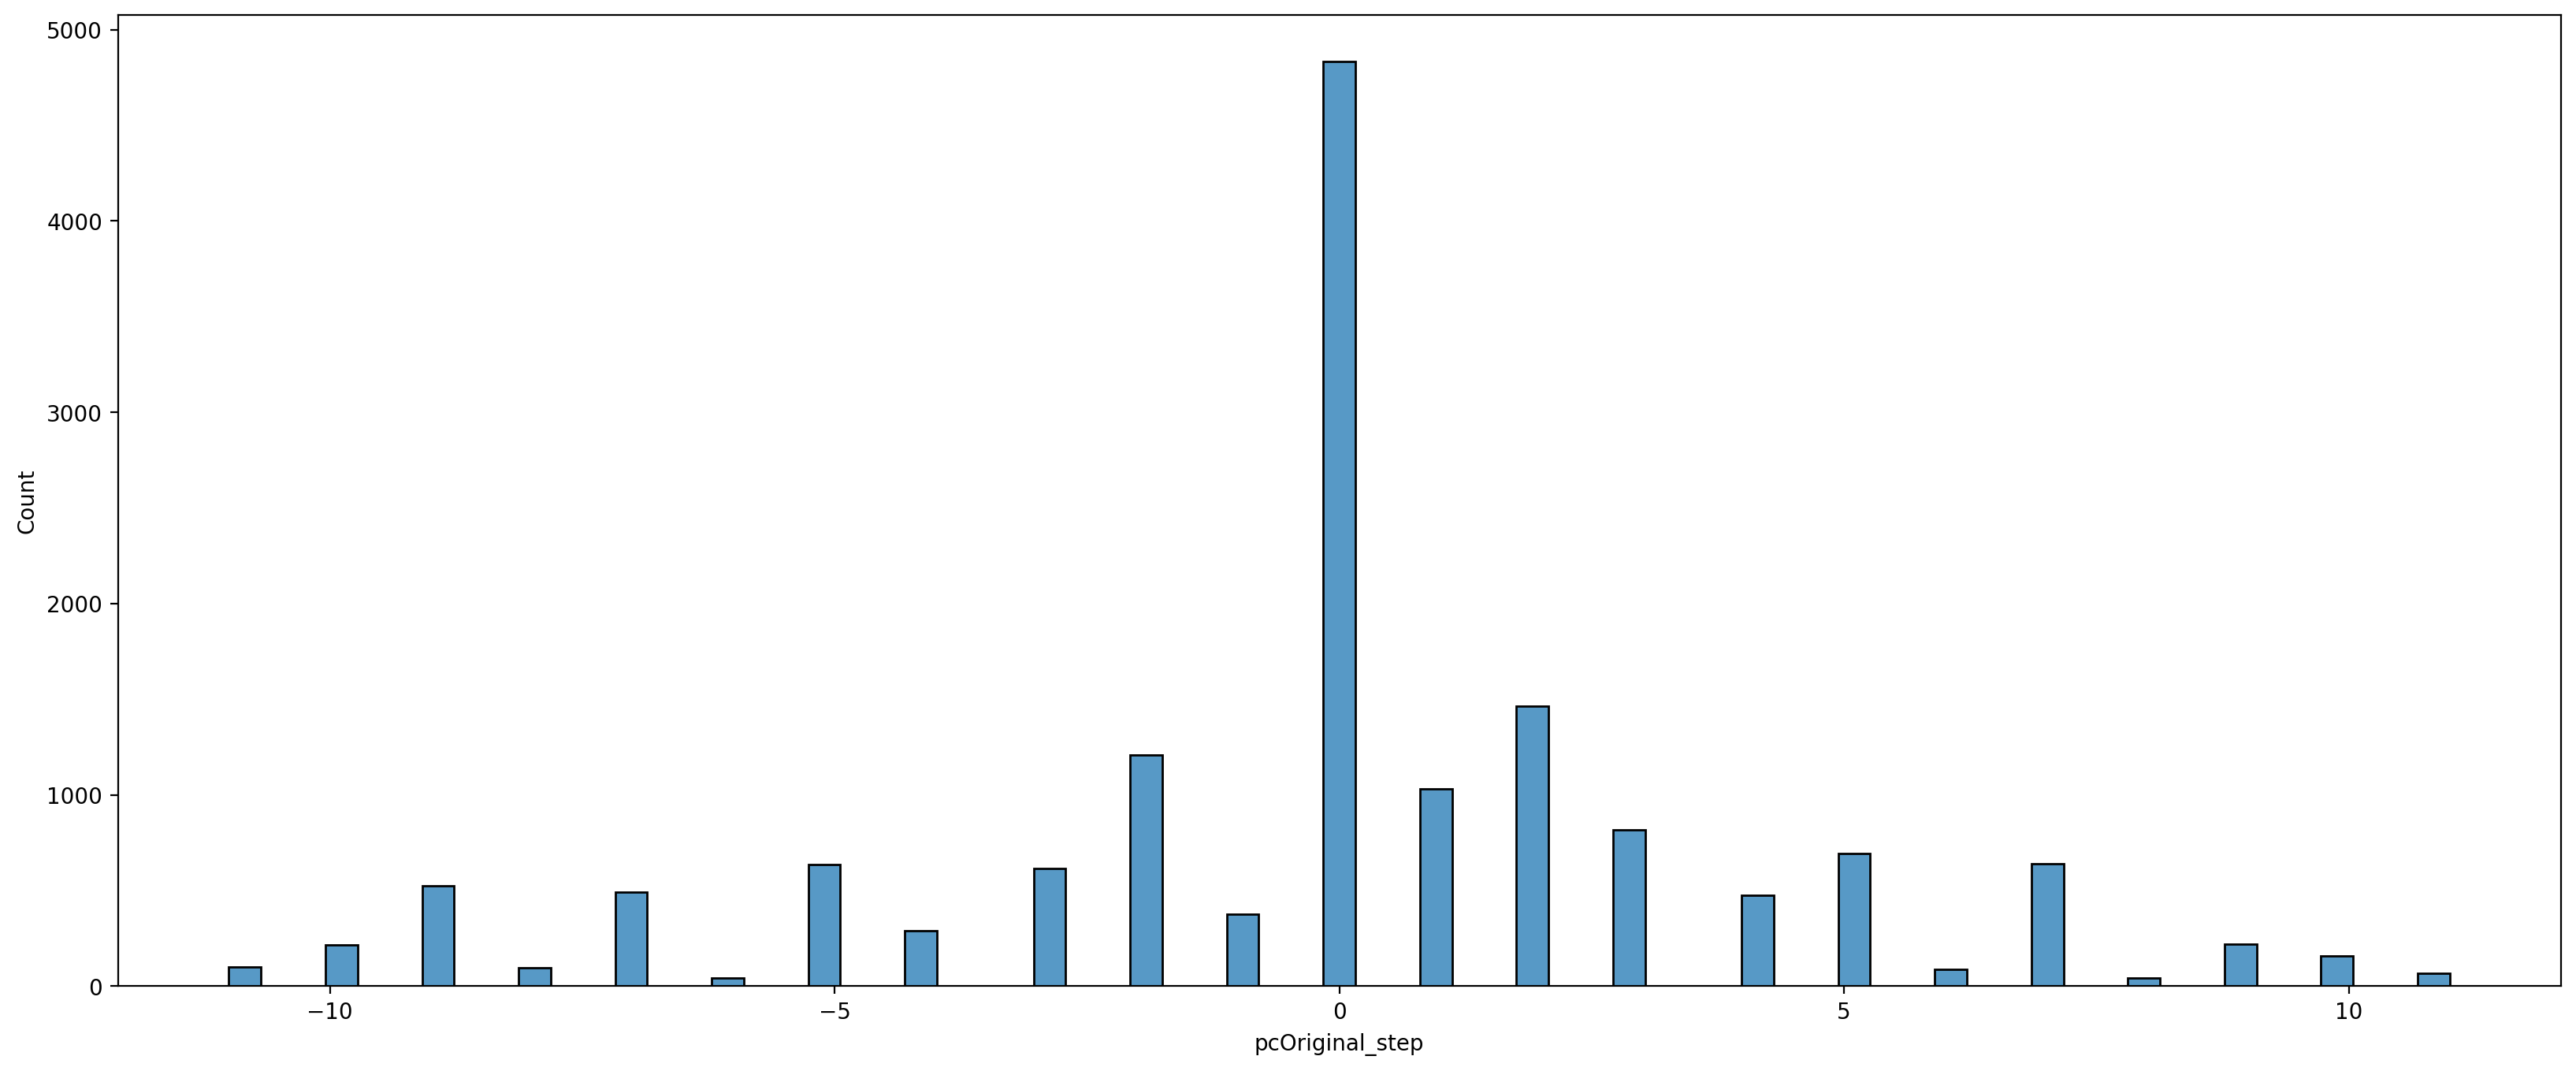

"\ndf = dataframe_all.sort_values(by='inversion_cardinality')\nplt.figure(figsize=[20, 8])\nsns.histplot(df['inversion_cardinality'])\nplt.show()\n\ndf = dataframe_all.sort_values(by='inversion_cardinality_step')\nplt.figure(figsize=[20, 8])\nsns.histplot(df['inversion_cardinality_step'])\nplt.show()\n"

In [26]:
df = dataframe_all.sort_values(by='root_pitch')
plt.figure(figsize=[20, 8])
'''
def splitnote(val):
    if isinstance(val, list):
        return '.'.join(val)
    else:
        return str(val)
'''    
sns.histplot(df['root_note'])
plt.xticks(rotation = 90)
plt.show()

df = dataframe_all.sort_values(by='root_step')
plt.figure(figsize=[20, 8])    
sns.histplot(df['root_step'])
plt.show()

df = dataframe_all.sort_values(by='duration')
plt.figure(figsize=[20, 8])     
sns.histplot(df['duration'])
plt.show()



step = 1./16.
    
def fractions(x, pos):
    # https://stackoverflow.com/questions/33780678/how-to-label-the-x-axis-in-fraction-numbers
    if np.isclose((x/step)%(1./step),0.):
        # x is an integer, so just return that
        return '{:.0f}'.format(x)
    else:
        # this returns a latex formatted fraction
        return '$\\frac{{{:2.0f}}}{{{:2.0f}}}$'.format(x/step,1./step)
        # if you don't want to use latex, you could use this commented
        # line, which formats the fraction as "1/13"
        ### return '{:2.0f}/{:2.0f}'.format(x/step,1./step)

df['duration_scaled'] = df['duration'] / 4
plt.figure(figsize=[20, 8])
hist = sns.histplot(df, x="duration_scaled", binwidth=0.005)
hist.xaxis.set_major_locator(mticker.MultipleLocator(step))
hist.xaxis.set_major_formatter(mticker.FuncFormatter(fractions))


df = dataframe_all.sort_values(by='duration_step')
plt.figure(figsize=[20, 8])
sns.histplot(df['duration_step'])
plt.show()

df['duration_step_scaled'] = df['duration_step'] / 4
plt.figure(figsize=[20, 8])
hist = sns.histplot(df, x="duration_step_scaled", binwidth=0.005)
hist.xaxis.set_major_locator(mticker.MultipleLocator(step))
hist.xaxis.set_major_formatter(mticker.FuncFormatter(fractions))

df = dataframe_all.sort_values(by='chord_interval')
plt.figure(figsize=[15, 8])
sns.histplot(df['chord_interval'])
plt.xticks(rotation = 90)
plt.show()

df = dataframe_all.sort_values(by='cardinality')
plt.figure(figsize=[20, 8])
sns.histplot(df['cardinality'])
plt.show()

df = dataframe_all.sort_values(by='cardinality_step')
plt.figure(figsize=[20, 8])
sns.histplot(df['cardinality_step'])
plt.show()

df = dataframe_all.sort_values(by='forteClass')
plt.figure(figsize=[20, 8])
sns.histplot(df['forteClass'])
plt.show()

df = dataframe_all.sort_values(by='forteClass_step')
plt.figure(figsize=[20, 8])
sns.histplot(df['forteClass_step'])
plt.show()

df = dataframe_all.sort_values(by='inversion')
plt.figure(figsize=[20, 8])
sns.histplot(df['inversion'])
plt.show()

df = dataframe_all.sort_values(by='inversion_step')
plt.figure(figsize=[20, 8])
sns.histplot(df['inversion_step'])
plt.show()

df = dataframe_all.sort_values(by='pcOriginal')
plt.figure(figsize=[20, 8])       
sns.histplot(df['pcOriginal'])
plt.show()

df = dataframe_all.sort_values(by='pcOriginal_step')
plt.figure(figsize=[20, 8])       
sns.histplot(df['pcOriginal_step'])
plt.show()
'''
df = dataframe_all.sort_values(by='inversion_cardinality')
plt.figure(figsize=[20, 8])
sns.histplot(df['inversion_cardinality'])
plt.show()

df = dataframe_all.sort_values(by='inversion_cardinality_step')
plt.figure(figsize=[20, 8])
sns.histplot(df['inversion_cardinality_step'])
plt.show()
'''

alle Daten


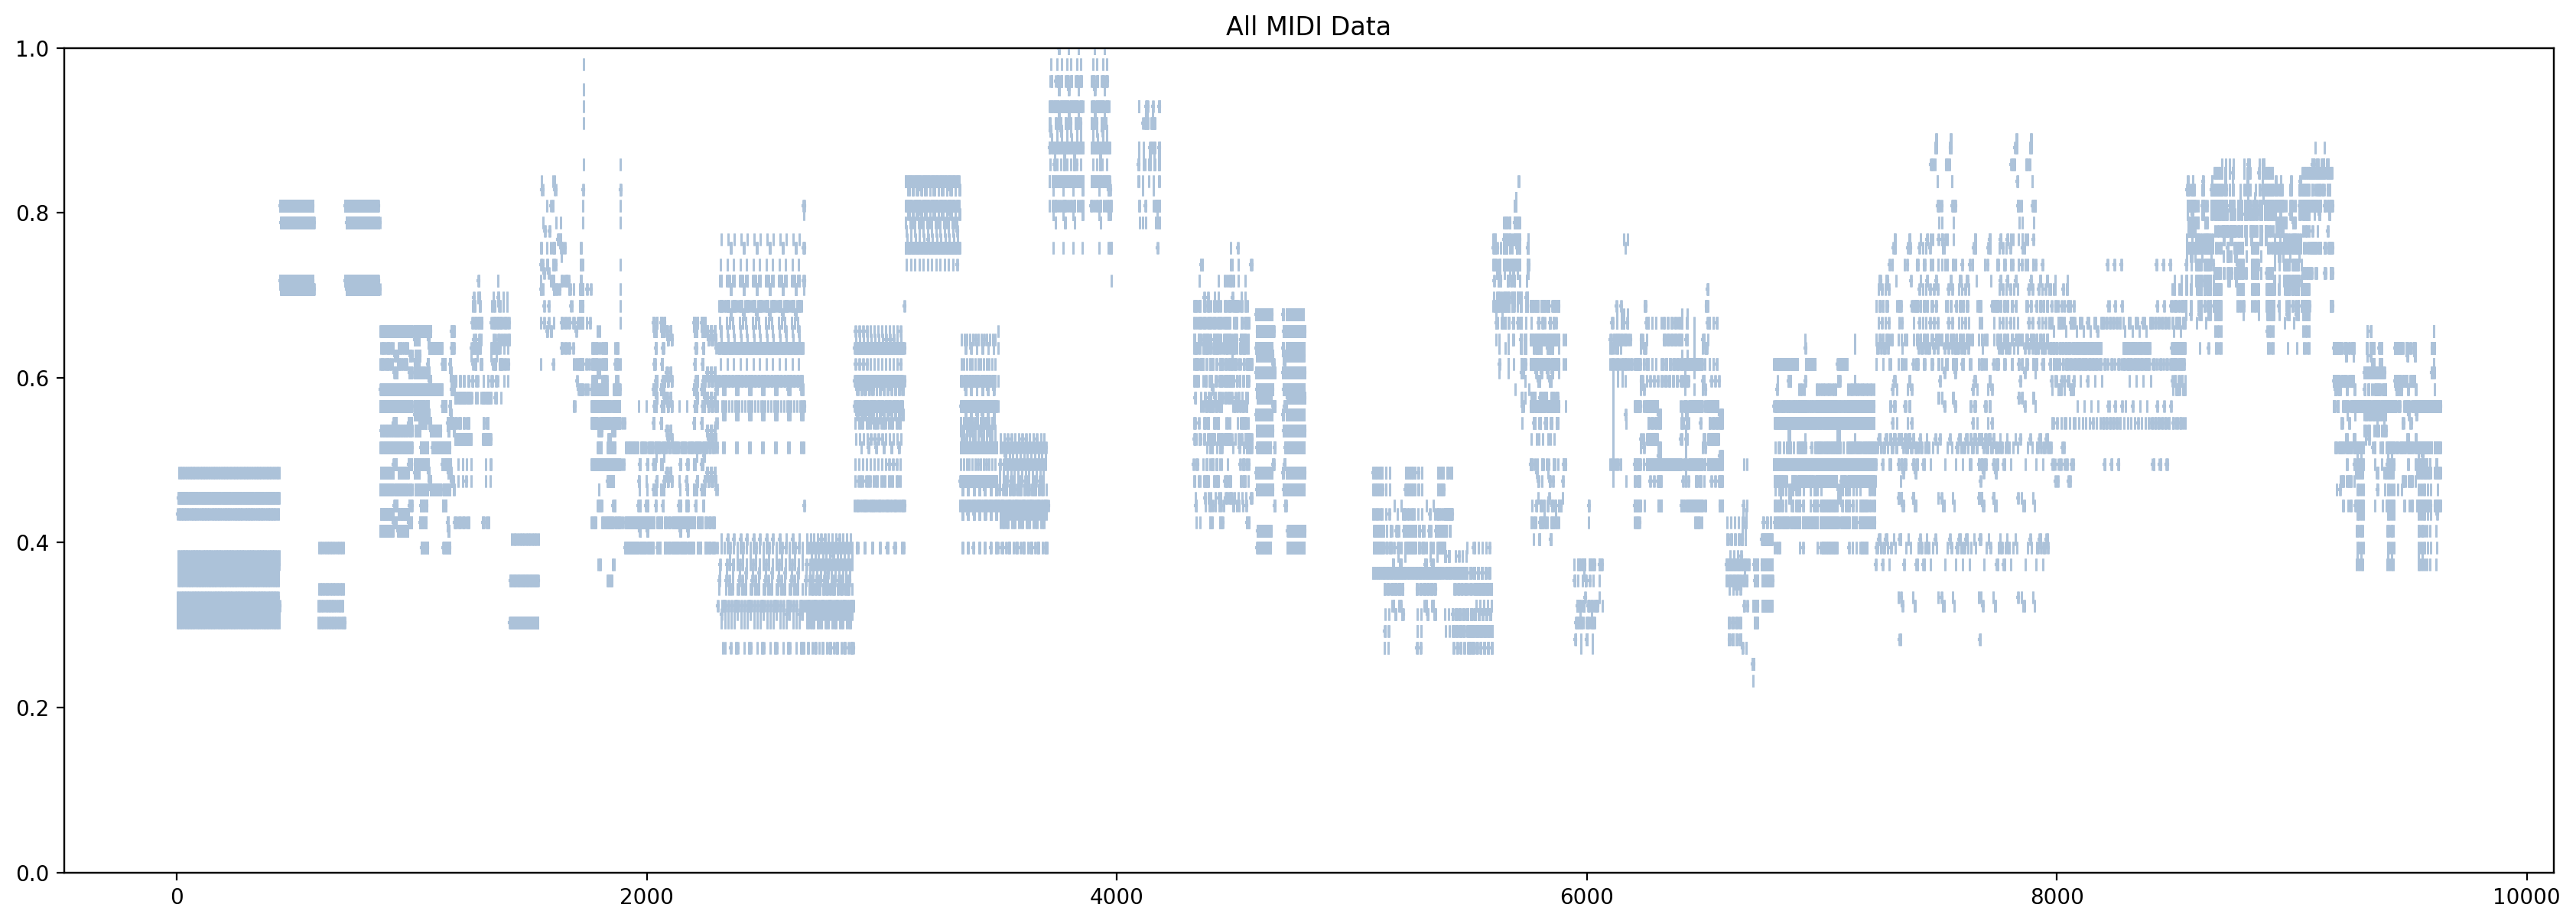

In [27]:
plot_piano_roll([dataframe_all])

# explore sequences
create raw sequences for exploration

## explore outlier

# OHE encoded sequences
now create sequences in one-hot encoded format for machine learning

In [28]:
for col, idx in zip(dataframe_all.columns, range(len(dataframe_all.columns))):
    print(idx, col)

0 notes
1 note_pitches
2 duration
3 duration_step
4 root_note
5 root_pitch
6 root_step
7 chord_interval
8 cardinality
9 cardinality_step
10 forteClass
11 forteClass_step
12 inversion
13 inversion_step
14 pcOriginal
15 pcOriginal_step


In [29]:
col_idx = [2, 3, 5, 6]
seq_len = 8

#print(dataframe_all.columns[idx])

X_train, y_train = np.array(()), np.array(())

mi = []
ma = []
ste = []

for idx in col_idx:
    uniq = np.unique(dataframe_all[dataframe_all.columns[idx]].values)
    
    i = np.nanmin(uniq)
    s = np.nanmin(np.diff(uniq))
    a = np.nanmax(uniq) + s
    mi.append(i)
    ma.append(a)
    ste.append(s)
    
    #print(uniq, i, a, s)

#print(mi, ma, ste)


def create_ohe_sequences(df, seq_length, column_indx, min_list, max_list, step_list):

    col_names = df.columns[column_indx]

    Xs, Ys, Fact, deFact = {}, {}, {}, {}
    
    for min, max, step, colname in zip(min_list, max_list, step_list, col_names):
    
        ohe_values = np.arange(min, max, step)
        ohe_values = np.append(ohe_values, values=[np.nan])
        ohe_replace = [x for x in range(len(ohe_values))]
        
        print(f'extracting sequences with len: {seq_len} from column: "{colname}", replacing {len(ohe_values)} values!')
        
        factorize_dict = dict(itertools.zip_longest(*[iter(ohe_values)], ohe_replace, fillvalue="-1"))
        defactorize_dict = dict(itertools.zip_longest(*[iter(ohe_replace)], ohe_values, fillvalue="-1"))

        df_factorized = df[colname].replace(factorize_dict)
    
        encoder = LabelBinarizer()
        encoder.fit(ohe_replace)
    
        df_transformed = encoder.transform(df_factorized)

        #print(df_transformed)
    
        xs, ys = [], []
        # Iterate over data indices
        for i in range((len(df_transformed) - seq_length)):
          	# Define inputs
            x = df_transformed[i : (i + seq_length)]
            # Define target
            y = df_transformed[(i + seq_length)]
      
            xs.append(x)
            ys.append(y)

        Xs[colname] = np.array(xs)
        Ys[colname] = np.array(ys)
        Fact[colname] = factorize_dict
        deFact[colname] = defactorize_dict
        
        print(f'extracted {len(xs)} sequences from column: "{colname}"!')
        
    return Xs, Ys, Fact, deFact

def create_factorized_sequences(df, seq_length, column_indx, min_list, max_list, step_list):
    col_names = df.columns[column_indx]

    Xs, Ys, Fact, deFact = {}, {}, {}, {}
    
    for min, max, step, colname in zip(min_list, max_list, step_list, col_names):
    
        ohe_values = np.arange(min, max, step)
        ohe_values = np.append(ohe_values, values=[np.nan])
        ohe_replace = [x for x in range(len(ohe_values))]
        
        print(f'factorizing column:  "{colname}", replacing {len(ohe_values)} values!')

        factorize_dict = dict(itertools.zip_longest(*[iter(ohe_values)], ohe_replace, fillvalue="-1"))
        defactorize_dict = dict(itertools.zip_longest(*[iter(ohe_replace)], ohe_values, fillvalue="-1"))
    
        df_factorized = df[colname].replace(factorize_dict)

        xs, ys = [], []
        # Iterate over data indices
        for i in range((len(df_factorized) - seq_length)):
          	# Define inputs
            x = df_factorized.iloc[i : (i + seq_length)]
            # Define target
            y = df_factorized.iloc[(i + seq_length)]
      
            xs.append(x)
            ys.append(y)

        Xs[colname] = np.array(xs)
        Ys[colname] = np.array(ys)
        Fact[colname] = factorize_dict
        deFact[colname] = defactorize_dict
    return Xs, Ys, Fact, deFact

X_train, y_train, factorizing_dict, defactorize_dict = create_ohe_sequences(dataframe_all, seq_len, col_idx, mi, ma, ste)
#X_train, y_train, factorizing_dict, defactorize_dict = create_factorized_sequences(dataframe_all, seq_len, col_idx, mi, ma, ste)

extracting sequences with len: 8 from column: "duration", replacing 34 values!
extracted 21408 sequences from column: "duration"!
extracting sequences with len: 8 from column: "duration_step", replacing 66 values!
extracted 21408 sequences from column: "duration_step"!
extracting sequences with len: 8 from column: "root_pitch", replacing 79 values!
extracted 21408 sequences from column: "root_pitch"!
extracting sequences with len: 8 from column: "root_step", replacing 94 values!
extracted 21408 sequences from column: "root_step"!


### get all sequences and target nan (Rest)
sequences where all x-values of a sequence are nan and y-target is also nan

In [30]:
for (Xkey, Xval), (ykey, yval) in zip(X_train.items(), y_train.items()):
    #print(Xkey)
   # print(Xkey, Xval, ykey, yval)
    #print(Xval[ : , :, -1] ,np.sum(Xval[ : , :, -1], axis=1), Xval.shape[1], yval[:,-1])
    where_all_nan = (np.sum(Xval[ : , : , -1], axis=1) == Xval.shape[1]) & (yval[:,-1] == 1)
    print(f'{Xkey}: {len(Xval[where_all_nan])} nan sequences | {len(Xval[where_all_nan]) / len(Xval) * 100:.5}% of data!')

duration: 0 nan sequences | 0.0% of data!
duration_step: 0 nan sequences | 0.0% of data!
root_pitch: 983 nan sequences | 4.5917% of data!
root_step: 983 nan sequences | 4.5917% of data!


we should consider removing them!!

In [31]:
X_train_clean, y_train_clean = {}, {}


print('original:')
for (Xkey, Xval), (ykey, yval) in zip(X_train.items(), y_train.items()):
    print(Xkey, len(Xval))
    X_train_clean[Xkey] = Xval[~where_all_nan]
    y_train_clean[ykey] = yval[~where_all_nan]

print('\n\ncleansed:')
for (Xkey, Xval), (ykey, yval) in zip(X_train_clean.items(), y_train_clean.items()):
    print(Xkey, len(Xval))

original:
duration 21408
duration_step 21408
root_pitch 21408
root_step 21408


cleansed:
duration 20425
duration_step 20425
root_pitch 20425
root_step 20425


### get all sequences with missing values after encoding

In [32]:
for (Xkey, Xval), (ykey, yval) in zip(X_train_clean.items(), y_train_clean.items()):
    #print(Xkey)

    where_missing_data = (np.sum(np.sum(Xval[ : , : , :], axis=2), axis=1) < Xval.shape[1]) | (np.sum(yval, axis=1) < 1)
    
    print(f'{Xkey}: {len(Xval[where_missing_data])} sequences with missing value after encoding | {len(Xval[where_missing_data]) / len(Xval) * 100:.5}% of data!')

duration: 0 sequences with missing value after encoding | 0.0% of data!
duration_step: 0 sequences with missing value after encoding | 0.0% of data!
root_pitch: 0 sequences with missing value after encoding | 0.0% of data!
root_step: 0 sequences with missing value after encoding | 0.0% of data!


## create tensor dataset

In [33]:
class MidiDataset(TensorDataset):
    def __init__(self, mididata_x: dict, mididata_y: dict):
        super().__init__()
        for (keyx, x), (keyy, y) in zip(mididata_x.items(), mididata_y.items()):
            if keyx == 'duration':
                self.duration_data = torch.from_numpy(x).float().to(DEVICE)
            elif keyx == 'duration_step':
                self.duration_step_data = torch.from_numpy(x).float().to(DEVICE)
            elif keyx == 'root_pitch':
                self.root_pitch_data = torch.from_numpy(x).float().to(DEVICE)
            elif keyx == 'root_step':
                self.root_step_data = torch.from_numpy(x).float().to(DEVICE)

            if keyy == 'duration':
                self.duration_label = torch.from_numpy(y).float().to(DEVICE)
            elif keyy == 'duration_step':
                self.duration_step_label = torch.from_numpy(y).float().to(DEVICE)
            elif keyy == 'root_pitch':
                self.root_pitch_label = torch.from_numpy(y).float().to(DEVICE)
            elif keyy == 'root_step':
                self.root_step_label = torch.from_numpy(y).float().to(DEVICE)

        assert(self.duration_data.shape[0] == self.duration_label.shape[0])

        #print(self.root_pitch_data.shape, self.duration_data.shape, self.root_pitch_label.shape, self.duration_label.shape)

    def __len__(self):
        return self.duration_data.shape[0]

    def __getitem__(self, idx):
        root_pitch_data = self.root_pitch_data[idx]
        root_step_data = self.root_step_data[idx]
        duration_data = self.duration_data[idx]
        duration_step_data = self.duration_step_data[idx]
        root_pitch_label = self.root_pitch_label[idx]
        root_step_label = self.root_step_label[idx]
        duration_label = self.duration_label[idx]
        duration_step_label = self.duration_step_label[idx]

        #print(root_pitch_data.shape, duration_data.shape, root_pitch_label.shape, duration_label.shape)
        
        return root_pitch_data, root_step_data, duration_data, duration_step_data, root_pitch_label, root_step_label, duration_label, duration_step_label

### let's hope I have enough VRAM

In [34]:
# Create TensorDataset
dataset_all = MidiDataset(
    X_train_clean, y_train_clean
)

print(len(dataset_all))

20425


## split dataset

In [35]:
generator1 = torch.Generator().manual_seed(42)


train_size = int(0.7 * len(dataset_all))

test_size = (len(dataset_all) - train_size)
val_size = test_size // 2

dataset_train, dataset_test = random_split(dataset_all, [train_size, test_size], generator=generator1)
dataset_val, dataset_test = random_split(dataset_test, [val_size, (test_size - val_size)], generator=generator1)

print(f'train size: {len(dataset_train)}\ntest size: {len(dataset_test)}\nvalidation size: {len(dataset_val)}')

train size: 14297
test size: 3064
validation size: 3064


# define model

In [36]:
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, num_lstm_layer, sequence_len, batch_size, momentum, dropout, data_embedding, num_embeddings, output_sizes):
        super(Net, self).__init__()

        
        ## Input: batch_size * seq_length
        ## Output: batch_size * seq_length * embedding_dimension
        
        
        #self.cardinality_embedding = nn.Embedding(embedding_size, sequence_len)
        #self.forteClass_embedding = nn.Embedding(embedding_size, sequence_len)
        #self.inversion_embedding = nn.Embedding(embedding_size, sequence_len)
        #self.pcOriginal_embedding = nn.Embedding(embedding_size, sequence_len)

        ## Input: seq_length * batch_size * input_size (embedding_dimension in this case)
        ## Output: seq_length * batch_size * hidden_size
        ## last_hidden_state: batch_size * hidden_size
        ## last_cell_state: batch_size * hidden_size
        self.momentum = momentum
        self.dropout = dropout
        self.data_embedding = data_embedding
        self.num_lstm_layer = num_lstm_layer
        self.hidden_size = hidden_size
        
        self.LSTM_1 = nn.LSTM(
            input_size=input_size,
            hidden_size=self.hidden_size,
            num_layers=num_lstm_layer,
            batch_first=True,
        )
        self.LSTM_2 = nn.LSTM(
            input_size=hidden_size,
            hidden_size=self.hidden_size*2,
            num_layers=num_lstm_layer,
            batch_first=True,
        )
       
        for (key, out_size) in output_sizes.items():
            if key == 'duration':
                if self.data_embedding:
                    self.duration_embedding = nn.Embedding(num_embeddings=num_embeddings, embedding_dim=out_size)
                self.duration_fc = nn.Sequential(
                    nn.BatchNorm1d(self.hidden_size*2, eps=1e-05, momentum=self.momentum), 
                    nn.Dropout(p = self.dropout, inplace=False),
                    nn.Linear(self.hidden_size*2, self.hidden_size),
                    nn.ELU(),
                    nn.BatchNorm1d(self.hidden_size, eps=1e-05, momentum=self.momentum),
                    nn.Dropout(p = self.dropout, inplace=False),
                    nn.Linear(self.hidden_size, out_size),
                    nn.Softmax(), 
                )
                
                self.duration_accuracy = Accuracy(task="multiclass", num_classes=out_size)
                self.duration_out_size = out_size
            elif key == 'duration_step':
                if self.data_embedding:
                    self.duration_step_embedding = nn.Embedding(num_embeddings=num_embeddings, embedding_dim=out_size)
                self.duration_step_fc = nn.Sequential(
                    nn.BatchNorm1d(self.hidden_size*2, eps=1e-05, momentum=self.momentum), 
                    nn.Dropout(p=self.dropout, inplace=False),
                    nn.Linear(self.hidden_size*2, self.hidden_size),
                    nn.ELU(),
                    nn.BatchNorm1d(self.hidden_size, eps=1e-05, momentum=self.momentum),
                    nn.Dropout(p = self.dropout, inplace=False),
                    nn.Linear(self.hidden_size, out_size),
                    nn.Softmax(), 
                )
                
                self.duration_step_accuracy = Accuracy(task="multiclass", num_classes=out_size)
                self.duration_step_out_size = out_size
                
            elif key == 'root_pitch':
                if self.data_embedding:
                    self.root_pitch_embedding = nn.Embedding(num_embeddings=num_embeddings, embedding_dim=out_size)
                self.root_pitch_fc = nn.Sequential(
                    nn.BatchNorm1d(self.hidden_size*2, eps=1e-05, momentum=self.momentum), 
                    nn.Dropout(p = self.dropout, inplace=False),
                    nn.Linear(self.hidden_size*2, self.hidden_size),
                    nn.ELU(),
                    nn.BatchNorm1d(self.hidden_size, eps=1e-05, momentum=self.momentum),
                    nn.Dropout(p = self.dropout, inplace=False),
                    nn.Linear(self.hidden_size, out_size),
                    nn.Softmax(), 
                )
                
                self.root_pitch_accuracy = Accuracy(task="multiclass", num_classes=out_size)
                self.root_pitch_out_size = out_size
                
            elif key == 'root_step':
                if self.data_embedding:
                    self.root_step_embedding = nn.Embedding(num_embeddings=num_embeddings, embedding_dim=out_size)
                self.root_step_fc = nn.Sequential(
                    nn.BatchNorm1d(self.hidden_size*2, eps=1e-05, momentum=self.momentum),
                    nn.Dropout(p = self.dropout, inplace=False),
                    nn.Linear(self.hidden_size*2, self.hidden_size),
                    nn.ELU(),
                    nn.BatchNorm1d(self.hidden_size, eps=1e-05, momentum=self.momentum),
                    nn.Dropout(p = self.dropout, inplace=False),
                    nn.Linear(self.hidden_size, out_size),
                    nn.Softmax(), 
                )
                
                self.root_step_accuracy = Accuracy(task="multiclass", num_classes=out_size)
                self.root_step_out_size = out_size
                
        

    

        
        

    def forward(self, batch_idx, root_pitch_data, root_step_data, duration_data, duration_step_data):
       
        
        #embedd root pitch and duration
        #print(X_note_pitch.shape, X_note_duration.shape)
        if self.data_embedding:
            root_pitch_embedded = self.root_pitch_embedding(root_pitch_data)
            root_step_embedded = self.root_step_embedding(root_step_data) 
            duration_embedded = self.duration_embedding(duration_data)
            duration_step_embedded = self.duration_embedding(duration_step_data)

        #root_pitch_embedded = torch.squeeze(root_pitch_embedded)
        #duration_embedded = torch.squeeze(duration_embedded)

        #print(root_pitch_embedded.shape, duration_embedded.shape)
        
        # concat
            x = torch.cat((root_pitch_embedded, root_step_embedded, duration_embedded, duration_step_embedded), dim = 2)
        else:
            x = torch.cat((root_pitch_data, root_step_data, duration_data, duration_step_data), dim = 2)
        #x = torch.transpose(x, 1, 2)
        
        #print(x.shape)
        if batch_idx == 0:
            self.h0 = torch.zeros(self.num_lstm_layer, x.shape[0], self.hidden_size).to(DEVICE)
            # Initialize long-term memory
            self.c0 = torch.zeros(self.num_lstm_layer, x.shape[0], self.hidden_size).to(DEVICE)
    
            self.h1 = torch.zeros(self.num_lstm_layer, x.shape[0], self.hidden_size*2).to(DEVICE)
            # Initialize long-term memory
            self.c1 = torch.zeros(self.num_lstm_layer, x.shape[0], self.hidden_size*2).to(DEVICE)
        #print(self.c0)
        # Pass all inputs to lstm layer
        out_lstm_1, _ = self.LSTM_1(x, (self.h0, self.c0))

        out_lstm_2, _ = self.LSTM_2(out_lstm_1, (self.h1, self.c1))
        #print(out_lstm_1, out_lstm_1[:, -1, :])
        # pass lstm output to fully connected layers
        out_root_pitch = self.root_pitch_fc(out_lstm_2[:, -1, :])
        out_root_step = self.root_step_fc(out_lstm_2[:, -1, :])
        out_duration = self.duration_fc(out_lstm_2[:, -1, :])
        out_duration_step = self.duration_step_fc(out_lstm_2[:, -1, :])
        
        
        return out_root_pitch, out_root_step, out_duration, out_duration_step

    def fit(self):
        pass
        



## define parameters

In [37]:


output_sizes = dict(map(lambda key, value : (key, len(value.values())) , factorizing_dict.keys(), factorizing_dict.values()))

# = {[key:[x for x in X_train.values()] for key in ]}
print(output_sizes)

input_size = np.sum([x for x in output_sizes.values()])
print(input_size)

{'duration': 34, 'duration_step': 66, 'root_pitch': 79, 'root_step': 94}
273


In [38]:
best_params = {
    'num_lstm_layer': 1,
    #embedding_size = min(50, m+1// 2). Where m is the number of categories so if you have m=10 you will have an embedding size of 5.
    'num_embeddings': np.minimum(50, input_size + 1 // 2),
    'data_embedding': False,
    'momentum' : 0.01, ## 0.99 in tensorflow
    'dropout': 0.60,
    'sequence_len': seq_len,
    'batch_size': 40,
    'hidden_size': int(input_size * 1.33),
    'input_size': input_size,
    'output_sizes' : output_sizes
}

In [39]:
for param, val in best_params.items():
    print(f'{param}: {val}')
    

num_lstm_layer: 1
num_embeddings: 50
data_embedding: False
momentum: 0.01
dropout: 0.6
sequence_len: 8
batch_size: 40
hidden_size: 363
input_size: 273
output_sizes: {'duration': 34, 'duration_step': 66, 'root_pitch': 79, 'root_step': 94}


In [40]:
## load data into dataloader
dataloader_train = DataLoader(
  dataset_train, shuffle=False, batch_size=best_params['batch_size']#, num_workers = 4
)

dataloader_validation = DataLoader(
  dataset_val, shuffle=False, batch_size=best_params['batch_size']#, num_workers = 4
)

# train

In [41]:

## create net
net = Net(**best_params).to(DEVICE)


In [42]:
print(net)

Net(
  (LSTM_1): LSTM(273, 363, batch_first=True)
  (LSTM_2): LSTM(363, 726, batch_first=True)
  (duration_fc): Sequential(
    (0): BatchNorm1d(726, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
    (1): Dropout(p=0.6, inplace=False)
    (2): Linear(in_features=726, out_features=363, bias=True)
    (3): ELU(alpha=1.0)
    (4): BatchNorm1d(363, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
    (5): Dropout(p=0.6, inplace=False)
    (6): Linear(in_features=363, out_features=34, bias=True)
    (7): Softmax(dim=None)
  )
  (duration_accuracy): MulticlassAccuracy()
  (duration_step_fc): Sequential(
    (0): BatchNorm1d(726, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
    (1): Dropout(p=0.6, inplace=False)
    (2): Linear(in_features=726, out_features=363, bias=True)
    (3): ELU(alpha=1.0)
    (4): BatchNorm1d(363, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
    (5): Dropout(p=0.6, inplace=False)
    (6): Linea

In [43]:
def calc_rateofchange(mean_losses):
    if len(mean_losses) < 2: return 0
    #x = np.log(np.abs(np.prod(np.diff(mean_losses) * 1e3)))
    return np.diff(mean_losses)[0]
    #return 1 / (1 + np.exp(-x))
    #return  if len(mean_losses) > 1 else 0

In [ ]:
num_epochs = 4000
learning_rate= 0.6

rateofchange_batches = []
rateofchange_val_batches = []
mean_val_batch_losses = []
mean_batch_losses = []
epoch_losses = []



criterion0 = nn.CrossEntropyLoss()
criterion1 = nn.CrossEntropyLoss()
criterion2 = nn.CrossEntropyLoss()
criterion3 = nn.CrossEntropyLoss()

optimizer = SGD(net.parameters(), lr=learning_rate)
with tqdm(range(num_epochs), unit="epoch") as tepoch:
    tepoch.set_description(f"Training")
    for epoch in tepoch:
        batch_losses = []
        net.train()
        for batch_idx, (root_pitch_data, root_step_data, duration_data, duration_step_data, root_pitch_label, root_step_label, duration_label, duration_step_label) in enumerate(dataloader_train):
            ## exclude last "incomplete" batch
            if len(root_pitch_data) == best_params['batch_size']:
    
                optimizer.zero_grad()
                outputs_root_pitch, outputs_root_step, outputs_duration, outputs_duration_step = net(batch_idx, root_pitch_data, root_step_data, duration_data, duration_step_data)
        
                loss_root_pitch = criterion0(outputs_root_pitch, root_pitch_label)
                if (batch_idx < 1):
                    pass
                    #print('true:',[x.item() for x in torch.argmax(root_pitch_label, dim=1, keepdim=True)])
                    #print('predict:',[x.item() for x in torch.argmax(outputs_root_pitch, dim=1, keepdim=True)])
                    #print('loss', loss_root_pitch.item())
                loss_root_step = criterion1(outputs_root_step, root_step_label)
                loss_duration = criterion2(outputs_duration, duration_label)
                loss_duration_step = criterion3(outputs_duration_step, duration_step_label)
                # Compute total loss
                loss = loss_root_pitch + loss_root_step + loss_duration + loss_duration_step
                loss.backward()
                
                batch_losses.append(loss.item())
                optimizer.step()
                
        val_batch_losses = []        
        net.eval()
        with torch.no_grad():
            for idx, (root_pitch_data, root_step_data, duration_data, duration_step_data, root_pitch_label, root_step_label, duration_label, duration_step_label) in enumerate(dataloader_validation):
                if len(root_pitch_data) == best_params['batch_size']:
                    outputs_root_pitch, outputs_root_step, outputs_duration, outputs_duration_step = net(batch_idx, root_pitch_data, root_step_data, duration_data, duration_step_data)
                    ## validation losses
                    loss_root_pitch = criterion0(outputs_root_pitch, root_pitch_label)
                    loss_root_step = criterion1(outputs_root_step, root_step_label)
                    loss_duration = criterion2(outputs_duration, duration_label)
                    loss_duration_step = criterion3(outputs_duration_step, duration_step_label)
                    loss = loss_root_pitch + loss_root_step + loss_duration + loss_duration_step
                    val_batch_losses.append(loss.item())
        
        mean_batch_loss = np.mean(batch_losses)
        mean_val_batch_loss = np.mean(val_batch_losses)
        #print(mean_batch_loss,mean_batch_losses[-2:], np.diff(mean_batch_losses[-2:]))
        mean_batch_losses.append(mean_batch_loss)
        mean_val_batch_losses.append(mean_val_batch_loss)
        rateofchange_batch = calc_rateofchange(mean_batch_losses[-2:]) 
        rateofchange_val_batch = calc_rateofchange(mean_val_batch_losses[-2:])

        rateofchange_batches.append(rateofchange_val_batch)
        rateofchange_val_batches.append(rateofchange_val_batch)
        
        '''
        epochd = {'Train loss': f'{mean_batch_loss:.4f} ({(mean_batch_loss - mean_batch_losses[(epoch-1 if epoch > 0 else 0)]):.4f})',
                'Validation loss': f'{mean_val_batch_loss:.4f} ({(mean_batch_losses - mean_val_batch_losses[(epoch-1 if epoch > 0 else 0)]):.4f})'
                 }
        '''
        epochd = {'Train loss': f'{mean_batch_loss:.4f} ({rateofchange_batch:.4f})',
                'Validation loss': f'{mean_val_batch_loss:.4f} ({rateofchange_val_batch:.4f})'
                 }
        epoch_losses.append(batch_losses)
        tepoch.set_postfix(epochd)
        #if (epoch+1) % 100 == 0:
        #print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {mean_batch_loss:.4f} ({mean_batch_loss - mean_batch_losses[(epoch-1 if epoch > 0 else 0)]:.3f})')
    
    

Training:  26%|▎| 1030/4000 [52:03<2:27:32,  2.98s/epoch, Train loss=14.0439 (0.0001), Validation loss=14.1211 (0.0070)

In [ ]:
print(np.mean(epoch_losses))

In [ ]:
fig = plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, num_epochs + 1, 1), mean_batch_losses, color='tab:orange', label='train loss')
plt.plot(np.arange(1, num_epochs + 1, 1), mean_val_batch_losses, color='tab:green', label='validation loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid()
plt.legend()
plt.show()

In [ ]:
fig = plt.figure(figsize=(16, 12))

plt.plot(np.arange(1, num_epochs + 1, 1), rateofchange_val_batches, color='tab:green', label='validation loss rate of change')
plt.plot(np.arange(1, num_epochs + 1, 1), rateofchange_batches, color='tab:orange', label='train loss rate of change')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid()
plt.legend()
plt.show()

In [ ]:
dataloader_test = DataLoader(
    dataset_test, shuffle=False, batch_size = 1#, num_workers = 4
)


y_preds_root_pitch = []
y_preds_root_step = []
y_preds_duration = []
y_preds_duration_step = []
y_trues_root_pitch = []
y_trues_root_step = []
y_trues_duration = []
y_trues_duration_step = []

def evaluate_model(model, dataloader_test):
    # Define accuracy metrics
    #acc_root_note = Accuracy(task="multiclass", num_classes=30)
    #acc_chord_interval = Accuracy(task="multiclass", num_classes=6)

    model.eval()
    with torch.no_grad():
        for batch_idx, (root_pitch_data, root_step_data, duration_data, duration_step_data, root_pitch_label, root_step_label, duration_label, duration_step_label) in enumerate(dataloader_test):
            # Obtain model outputs
            #print(batch_idx
            if len(root_pitch_data) == 1:
                outputs_root_pitch, outputs_root_step, outputs_duration, outputs_duration_step = net(batch_idx, root_pitch_data, root_step_data, duration_data, duration_step_data)

                y_preds_root_pitch.append(outputs_root_pitch.argmax().item())
                y_preds_root_step.append(outputs_root_step.argmax().item())
                y_preds_duration.append(outputs_duration.argmax().item())
                y_preds_duration_step.append(outputs_duration_step.argmax().item())

                y_trues_root_pitch.append(root_pitch_label.argmax().item())
                y_trues_root_step.append(root_step_label.argmax().item())
                y_trues_duration.append(duration_label.argmax().item())
                y_trues_duration_step.append(duration_step_label.argmax().item())
                
                model.root_pitch_accuracy(outputs_root_pitch.round(), root_pitch_label)
                model.root_step_accuracy(outputs_root_step.round(), root_step_label)
                model.duration_accuracy(outputs_duration.round(), duration_label)
                model.duration_step_accuracy(outputs_duration_step.round(), duration_step_label)
                
    print(f"Accuracy score:")
    print(f"Root pitch: {model.root_pitch_accuracy.compute()}")
    print(f"Root step: {model.root_step_accuracy.compute()}")
    print(f"Root duration: {model.duration_accuracy.compute()}")
    print(f"Root duration step: {model.duration_step_accuracy.compute()}")

evaluate_model(net, dataloader_test)




In [ ]:
cnf_matrices_root_pitch = confusion_matrix(y_preds_root_pitch, y_trues_root_pitch)
cnf_matrices_root_step = confusion_matrix(y_preds_root_step, y_trues_root_step)
cnf_matrices_duration = confusion_matrix(y_preds_duration, y_trues_duration)
cnf_matrices_duration_step = confusion_matrix(y_preds_duration_step, y_trues_duration_step)

In [ ]:
cnf_matrices = [cnf_matrices_duration, cnf_matrices_duration_step, cnf_matrices_root_pitch, cnf_matrices_root_step]

In [ ]:
#defactorize_dict

In [ ]:
for cnf_matrix, (target, value_dict) in zip(cnf_matrices, defactorize_dict.items()):


    def format_fn(tick_val, tick_pos):
        if int(tick_val) in range(len(value_dict)):
            return value_dict[int(tick_val)]
        else:
            return ''

    plt.figure(figsize=(10, 10))
    
        
    heatmap = sns.heatmap(cnf_matrix/np.sum(cnf_matrix), annot=False, fmt='.2%', cmap='Blues')
    heatmap.set_title(target)
    heatmap.set_ylabel('True label')
    heatmap.yaxis.set_major_formatter(format_fn)
    heatmap.set_xlabel('Predicted label')
    heatmap.xaxis.set_major_formatter(format_fn)
    if cnf_matrix.shape[0] > 10:
        heatmap.tick_params(axis='x', rotation=90)
        heatmap.tick_params(axis='y', rotation=0)
    plt.show()

In [ ]:
plt.figure(figsize=(10, 10))
plt.title('root_step')
sns.heatmap(cnf_matrices_root_step/np.sum(cnf_matrices_root_step), annot=False, fmt='.2%', cmap='Blues')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [ ]:
plt.figure(figsize=(10, 10))
plt.title('duration')
sns.heatmap(cnf_matrices_duration/np.sum(cnf_matrices_duration), annot=False, fmt='.2%', cmap='Blues')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [ ]:
plt.figure(figsize=(10, 10))
plt.title('duration_step')
sns.heatmap(cnf_matrices_duration_step/np.sum(cnf_matrices_duration_step), annot=False, fmt='.2%', cmap='Blues')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [ ]:
root_pitch_data, root_step_data, duration_data, duration_step_data, root_pitch_label, root_step_label, duration_label, duration_step_label = list(dataloader_test)[0]

with torch.no_grad():
    outputs = net(0, root_pitch_data, root_step_data, duration_data, duration_step_data)

    for outputs_root_pitch, outputs_root_step, outputs_duration, outputs_duration_step in zip(*outputs):
        print('-')
        print( f'root_pitch: {defactorize_dict["root_pitch"][outputs_root_pitch.argmax().item()]}')
        print( f'root_step: {defactorize_dict["root_step"][outputs_root_step.argmax().item()]}')
        print( f'duration: {defactorize_dict["duration"][outputs_duration.argmax().item()]}')
        print( f'duration_step: {defactorize_dict["duration_step"][outputs_duration_step.argmax().item()]}')

In [ ]:
dataframe_all.columns

In [ ]:
start_pitch = 69.
start_duration = 0.5

df_predict = pd.DataFrame(columns=dataframe_all.columns, index=[0])
df_predict['root_pitch'] = start_pitch
df_predict['root_step'] = 0.
df_predict['duration'] = start_duration
df_predict['duration_step'] = 0.
print(df_predict)
X_train, y_train = create_ohe_sequences(df_predict, 0, col_idx, mi, ma, ste)


In [ ]:
X_train['duration_step']

<hr style="border: solid 3px blue;">